# **감사의견 종합 EDA**
## **목적: 2분기 후 상장폐지 여부 예측을 위한 탐색적 데이터 분석**

### 분석 구성
1. 데이터 로드 및 기본 탐색
2. 개별 변수 분포 분석
3. 핵심 관계 분석 (감사의견 ↔ 상장폐지)
4. 시계열 트렌드 분석
5. 두 모델 예측 결합 및 리스크 스코어링
6. 2분기 후 상장폐지 예측 분석
7. 위험 종목 식별 및 정리

In [12]:
# ── 0. 라이브러리 임포트 ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib import rc
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

# 색상 팔레트 정의
COLOR_SAFE   = '#4C72B0'   # 파랑 - 정상
COLOR_WARN   = '#FF8C00'   # 주황 - 경고
COLOR_DANGER = '#D62728'   # 빨강 - 위험
COLOR_DELIST = '#9467BD'   # 보라 - 상장폐지

print('라이브러리 로드 완료')

# ── 1-1. 데이터 로드 (관리종목 제외, 감사의견 중심) ───────────────────────────────────

# (A) 전체 학습 데이터 (감사의견 + 상장폐지 중심)
# 로드 후 '관리종목 여부' 컬럼은 즉시 제거하여 분석에서 배제합니다.
cd = pd.read_csv('clean_data.csv', encoding='utf-8-sig')
if '관리종목 여부' in cd.columns:
    cd = cd.drop(columns=['관리종목 여부'])

# (B) 감사의견 모델 예측 결과 (2025Q1~Q3)
# 감사의견 모델의 Class별 확률 및 예측값이 포함된 데이터
ap = pd.read_csv('audit_prediction_results.csv', encoding='utf-8-sig')

# (C) Y 레이블 데이터 (원본)
# 실제 상장폐지 여부를 확인하기 위한 원본 레이블
yl = pd.read_csv('Y_label_dataset.csv', encoding='utf-8-sig')

print(f'clean_data         : {cd.shape[0]:,}행 × {cd.shape[1]}열 (관리종목 컬럼 제거 완료)')
print(f'감사의견 예측 결과 : {ap.shape[0]:,}행 × {ap.shape[1]}열  ({sorted(ap["quarter"].unique())[0]} ~ {sorted(ap["quarter"].unique())[-1]})')
print(f'Y_label_dataset   : {yl.shape[0]:,}행 × {yl.shape[1]}열')

라이브러리 로드 완료
clean_data         : 39,767행 × 29열 (관리종목 컬럼 제거 완료)
감사의견 예측 결과 : 6,749행 × 7열  (2025Q1 ~ 2025Q3)
Y_label_dataset   : 54,130행 × 7열


In [13]:
# ── clean_data 기본 정보 ─────────────────────────────────────────────
print('=== clean_data 컬럼 목록 ===')
print(cd.columns.tolist())
print()
print('=== 기술통계 (수치형) ===')
cd.describe().T.round(4)

=== clean_data 컬럼 목록 ===
['stock_code', 'Name', 'quarter', 'Open', 'High', 'Low', 'Close', 'Volume_sum', 'ret_1q', 'logret_1q', 'cumret_4q', 'down_gap_q', 'vol_4q', 'vol_8q', 'max_drawdown_4q', 'ma4', 'ma8', 'ma4_ratio', 'ma_cross_4_8', 'mom_4q', 'vol_z_4q', 'vol_drop_ratio_4q', 'intraquarter_range', 'crash_count_4q', 'down_streak_1q', 'down_streak_4q_max', 'vol_mean_decline_q', '감사의견', '상장폐지 여부']

=== 기술통계 (수치형) ===


,count,mean,std,min,25%,50%,75%,max
stock_code,39767.0,1.096242e+05,1.271158e+05,20.0000,2.018000e+04,6.667000e+04,1.613900e+05,9.502200e+05
Open,39767.0,2.187101e+04,6.333059e+04,0.0000,3.020000e+03,6.700000e+03,1.680000e+04,1.885000e+06
High,39767.0,2.648735e+04,7.648998e+04,0.0000,3.755000e+03,8.250000e+03,2.056250e+04,2.407000e+06
Low,39767.0,1.848320e+04,5.454538e+04,0.0000,2.485000e+03,5.530000e+03,1.395000e+04,1.500000e+06
Close,39767.0,2.212820e+04,6.600023e+04,5.0000,3.000000e+03,6.600000e+03,1.667500e+04,1.900000e+06
Volume_sum,39767.0,4.521152e+07,2.774752e+08,0.0000,3.527736e+06,1.090773e+07,3.226323e+07,2.699062e+10
ret_1q,39767.0,1.140000e-02,3.169000e-01,-0.9946,-1.344000e-01,-2.820000e-02,8.930000e-02,1.613950e+01
logret_1q,39767.0,-2.290000e-02,2.656000e-01,-5.2156,-1.443000e-01,-2.860000e-02,8.560000e-02,2.841400e+00
cumret_4q,39767.0,8.040000e-02,7.801000e-01,-0.9946,-2.830000e-01,-8.380000e-02,2.082000e-01,4.123260e+01
down_gap_q,39767.0,3.229000e-01,4.676000e-01,0.0000,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00


In [14]:
# ── 1-3. 결측치 확인 ──────────────────────────────────────────────────────
print('=== clean_data 결측치 ===')
missing = cd.isnull().sum()
print(missing[missing > 0])
print(f'\n총 행 수: {len(cd):,}  |  결측치 없는 행: {cd.dropna().shape[0]:,}')
print()
print('=== 분기 범위 ===')
print(f'clean_data: {sorted(cd["quarter"].unique())[0]} ~ {sorted(cd["quarter"].unique())[-1]}')
print(f'종목 수: {cd["stock_code"].nunique():,}개')

=== clean_data 결측치 ===
Series([], dtype: int64)

총 행 수: 39,767  |  결측치 없는 행: 39,767

=== 분기 범위 ===
clean_data: 2021Q1 ~ 2025Q3
종목 수: 2,512개


# **개별 변수 분포 분석**
### 감사의견 등급별로 데이터가 어떻게 분포해 있는지 확인.

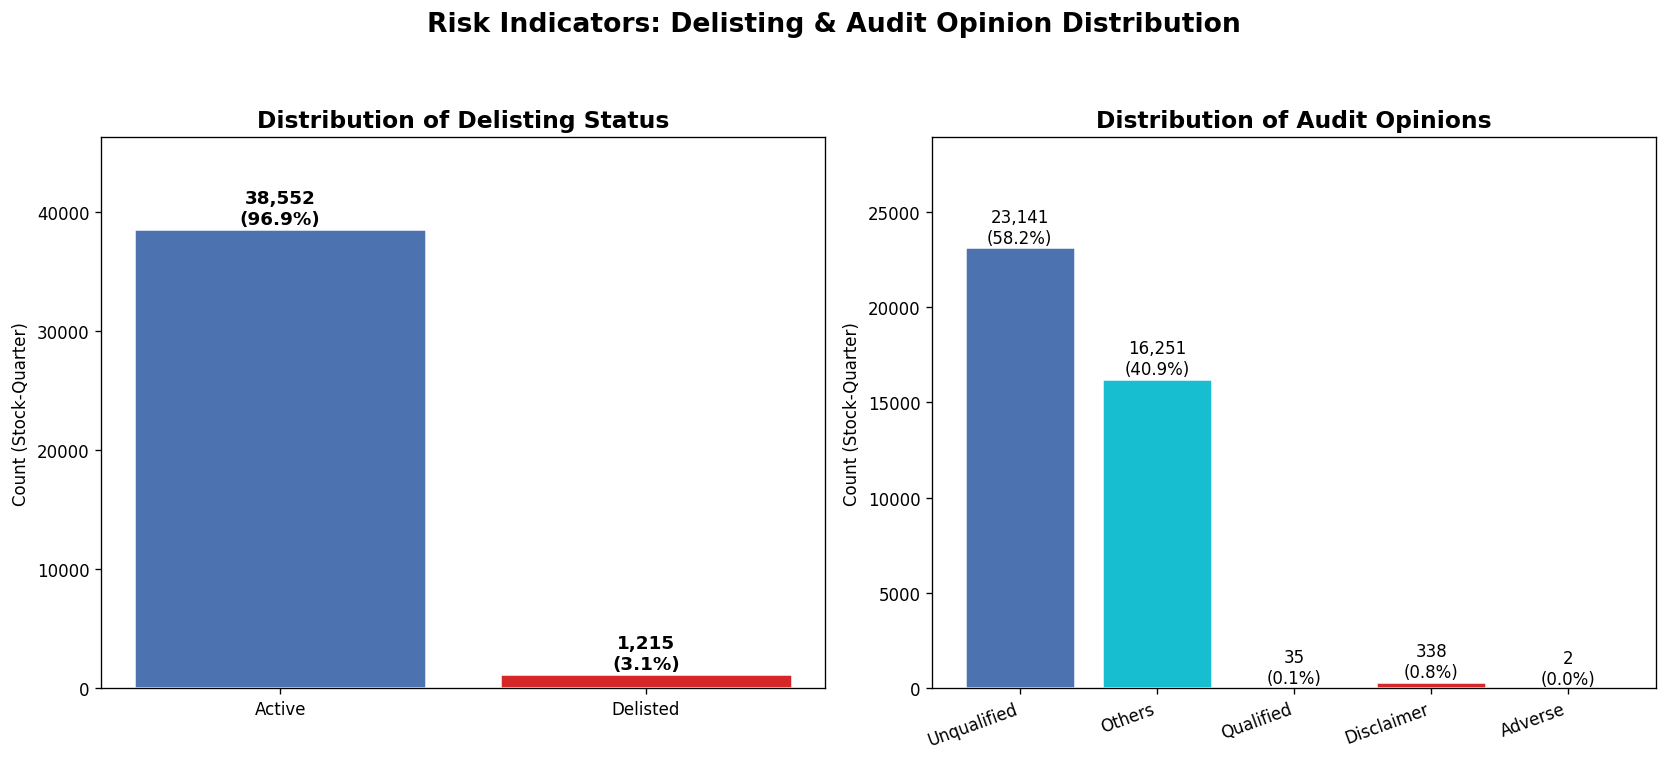


[데이터 요약]
  - 전체 데이터 레코드 수: 39,767건
  - 상장폐지 종목 비율  : 3.06%
  - 비적정 의견(위험) 비율: 0.94%
  - 기타/확인필요 의견 비율: 40.87%


In [16]:
# ── 2-1. 상장폐지 여부 및 감사의견 분포 시각화 (관리종목 배제) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (1) 상장폐지 여부 분포 (Distribution of Delisting Status)
# '정상'은 Active, '상장폐지'는 Delisted로 매핑하여 계산한다고 가정합니다.
delist_counts = cd['상장폐지 여부'].value_counts()
# 인덱스를 영문으로 변경 (정상 -> Active, 상장폐지 -> Delisted)
delist_counts.index = ['Active', 'Delisted']

colors_delist = [COLOR_SAFE, COLOR_DANGER] # Active: 초록, Delisted: 빨강
bars1 = axes[0].bar(delist_counts.index, delist_counts.values, color=colors_delist, edgecolor='white', linewidth=1.5)

axes[0].set_title('Distribution of Delisting Status', fontsize=14, fontweight='bold') # 상장폐지 여부 분포
axes[0].set_ylabel('Count (Stock-Quarter)') # 종목-분기 수

for bar, val in zip(bars1, delist_counts.values):
    pct = val / len(cd) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, delist_counts.max() * 1.2)

# (2) 감사의견 분포 (Distribution of Audit Opinions)
# 의견의 리스크 강도 순서로 영문 매핑:
# 적정(Unqualified), 기타/확인필요(Others), 한정(Qualified), 의견거절(Disclaimer), 부적정(Adverse)
opinion_mapping = {
    '적정': 'Unqualified',
    '기타/확인필요': 'Others',
    '한정': 'Qualified',
    '의견거절': 'Disclaimer',
    '부적정': 'Adverse'
}
# 데이터프레임 내의 한글 의견을 영문으로 치환
cd_eng = cd.copy()
cd_eng['감사의견_ENG'] = cd_eng['감사의견'].map(opinion_mapping)

opinion_order = ['Unqualified', 'Others', 'Qualified', 'Disclaimer', 'Adverse']
opinion_counts = cd_eng['감사의견_ENG'].value_counts().reindex(opinion_order, fill_value=0)

# 의견별 색상: Unqualified(초록), Others(청록), Qualified(주황), Disclaimer(빨강), Adverse(브라운)
opinion_colors = [COLOR_SAFE, '#17BECF', COLOR_WARN, COLOR_DANGER, '#8C564B']

bars2 = axes[1].bar(opinion_counts.index, opinion_counts.values, color=opinion_colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Distribution of Audit Opinions', fontsize=14, fontweight='bold') # 감사의견 분포 현황
axes[1].set_ylabel('Count (Stock-Quarter)') # 종목-분기 수
axes[1].set_xticklabels(opinion_counts.index, rotation=20, ha='right')

for bar, val in zip(bars2, opinion_counts.values):
    pct = val / len(cd) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[1].set_ylim(0, opinion_counts.max() * 1.25)

# 전체 중앙 제목: 핵심 리스크 지표(상장폐지·감사의견) 분포 현황
plt.suptitle('Risk Indicators: Delisting & Audit Opinion Distribution', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('fig_01_risk_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

# [요약 출력] 콘솔 출력은 한글 유지 (터미널은 대개 한글을 지원하므로)
print('\n[데이터 요약]')
print(f'  - 전체 데이터 레코드 수: {len(cd):,}건')
print(f'  - 상장폐지 종목 비율  : {delist_counts.get("Delisted", 0)/len(cd)*100:.2f}%')
print(f'  - 비적정 의견(위험) 비율: {(opinion_counts["Qualified"] + opinion_counts["Disclaimer"] + opinion_counts["Adverse"])/len(cd)*100:.2f}%')
print(f'  - 기타/확인필요 의견 비율: {opinion_counts["Others"]/len(cd)*100:.2f}%')


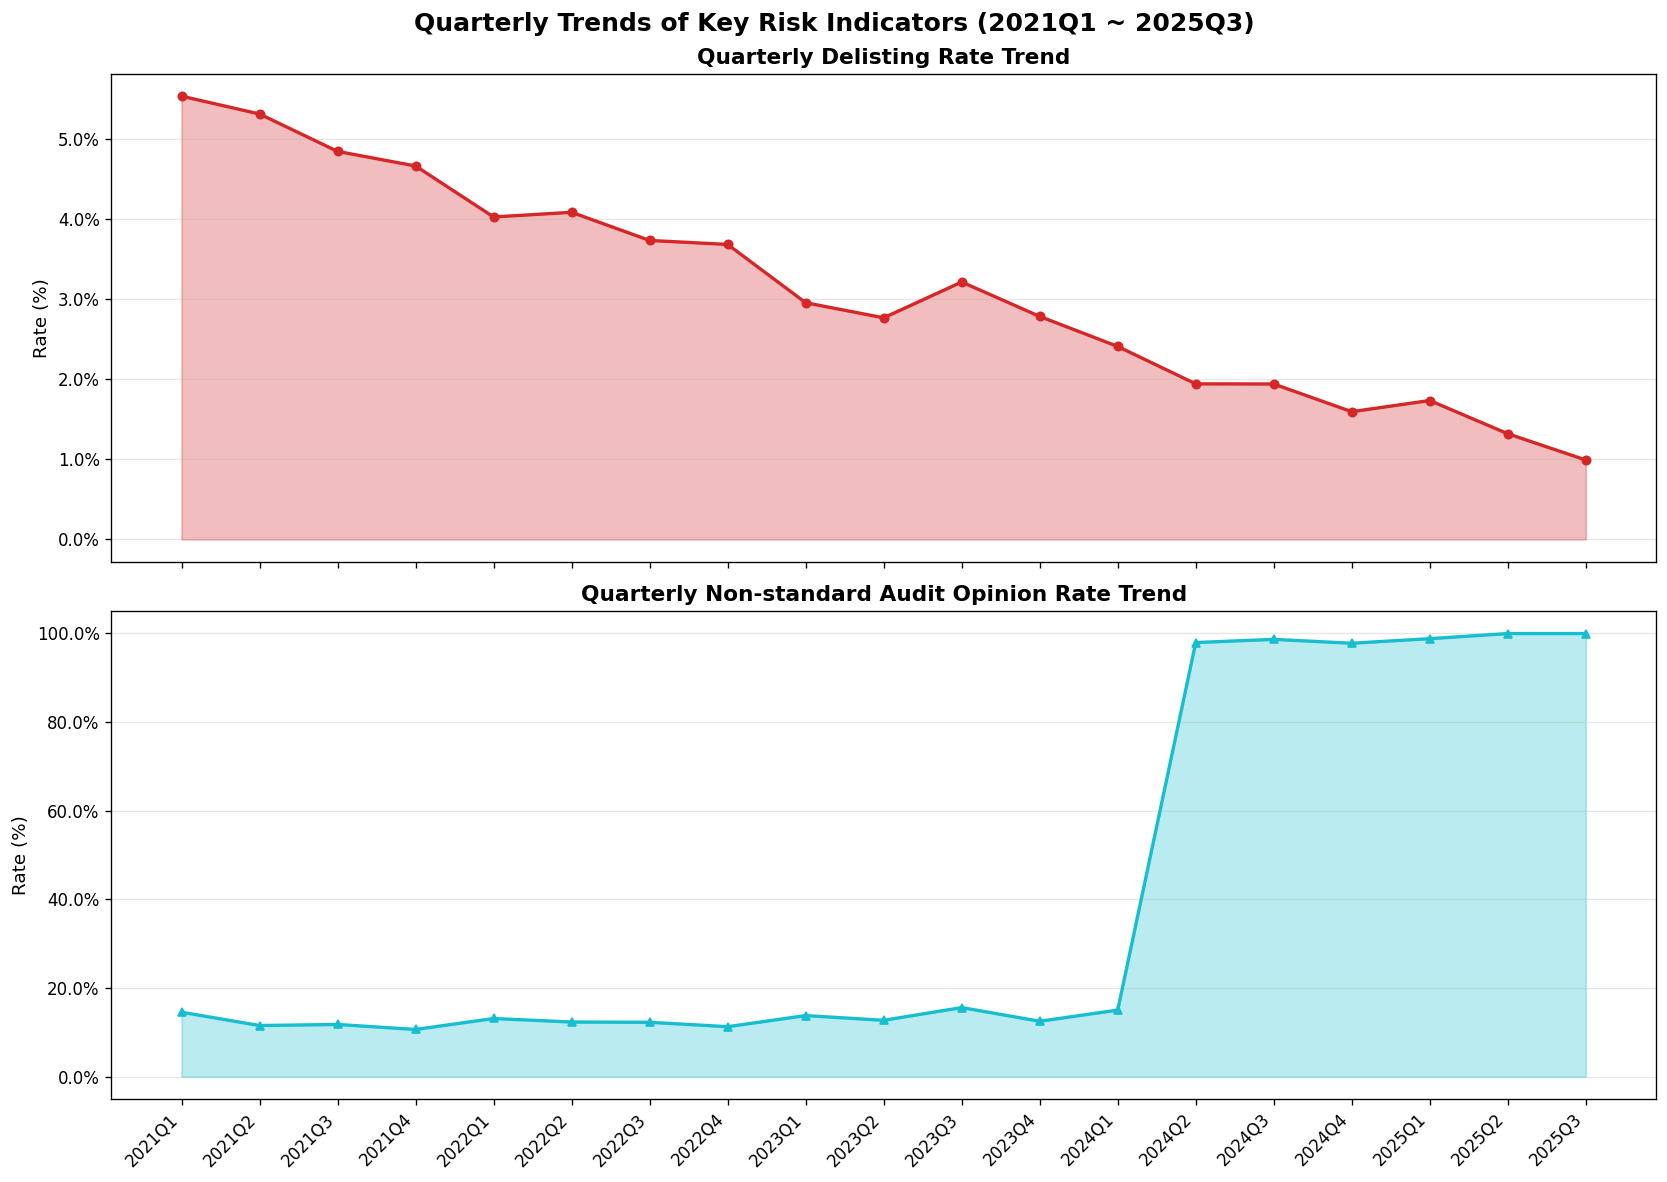

Analysis complete. 'Management Designation' has been excluded.


In [17]:
# ── 2-2. Quarterly Trends of Key Risk Indicators (주요 위험 지표 분기별 추이) ──────

# Aggregate data by quarter (분기별 데이터 집계)
quarter_stats = cd.groupby('quarter').agg(
    total_count=('stock_code', 'count'),
    delist_count=('상장폐지 여부', lambda x: (x == '상장폐지').sum()),
    # nonstandard_count: '적정'이 아닌 모든 감사의견 수
    nonstandard_count=('감사의견', lambda x: (~x.isin(['적정'])).sum())
).reset_index()

# Calculate rates (비율 계산)
quarter_stats['delist_rate']      = quarter_stats['delist_count'] / quarter_stats['total_count'] * 100
quarter_stats['nonstandard_rate'] = quarter_stats['nonstandard_count'] / quarter_stats['total_count'] * 100

# Plotting with 2 subplots (관리종목 제외, 2개의 서브플롯 구성)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

quarters = quarter_stats['quarter']
x = range(len(quarters))

# (1) Delisting Rate Trend (상장폐지 비율 추이)
axes[0].fill_between(x, quarter_stats['delist_rate'], alpha=0.3, color=COLOR_DANGER)
axes[0].plot(x, quarter_stats['delist_rate'], 'o-', color=COLOR_DANGER, linewidth=2, markersize=5)
axes[0].set_ylabel('Rate (%)', fontsize=11) # 비율 (%)
axes[0].set_title('Quarterly Delisting Rate Trend', fontsize=13, fontweight='bold') # 분기별 상장폐지 비율 추이
axes[0].grid(axis='y', alpha=0.3)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

# (2) Non-standard Audit Opinion Rate Trend (비적정 감사의견 비율 추이)
axes[1].fill_between(x, quarter_stats['nonstandard_rate'], alpha=0.3, color='#17BECF') # 기타/위험 색상 계열
axes[1].plot(x, quarter_stats['nonstandard_rate'], '^-', color='#17BECF', linewidth=2, markersize=5)
axes[1].set_ylabel('Rate (%)', fontsize=11) # 비율 (%)
axes[1].set_title('Quarterly Non-standard Audit Opinion Rate Trend', fontsize=13, fontweight='bold') # 분기별 비적정 감사의견 비율 추이
axes[1].grid(axis='y', alpha=0.3)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

# Set X-axis labels (X축 라벨 설정)
axes[1].set_xticks(x)
axes[1].set_xticklabels(quarters, rotation=45, ha='right')

# Overall Title (전체 제목)
plt.suptitle('Quarterly Trends of Key Risk Indicators (2021Q1 ~ 2025Q3)', fontsize=15, fontweight='bold')
# 주요 위험 지표 분기별 추이

plt.tight_layout()
plt.savefig('fig_02_quarterly_trends.png', bbox_inches='tight', dpi=150)
plt.show()

# Summary Output (요약 출력)
print(f"Analysis complete. 'Management Designation' has been excluded.")

# 핵심 관계 분석 (감사의견 ↔ 상장폐지)
### 감사의견 등급이 실제 2분기 후 상장폐지와 얼마나 강력한 상관관계를 갖는지 수치화.

In [19]:
# ── 3-1. Target Label Creation (2 Quarters Later) ───────────────────────────
# (2분기 후 상장폐지 여부 라벨 생성)

# Sorting for time-series shifting (시계열 정렬)
cd_sorted = cd.sort_values(['stock_code', 'quarter']).copy()

# Shift delisting status by 1 and 2 quarters (상장폐지 여부 1, 2분기 시프트)
cd_sorted['future_2q_delist'] = cd_sorted.groupby('stock_code')['상장폐지 여부'].shift(-2)
cd_sorted['future_1q_delist'] = cd_sorted.groupby('stock_code')['상장폐지 여부'].shift(-1)

# Create binary target label (1 = Delisting Risk, 0 = Safe)
# (이진 라벨 생성: 1 = 상장폐지 위험/폐지, 0 = 정상 유지)
cd_sorted['future_delist_binary'] = (cd_sorted['future_2q_delist'] == '상장폐지').astype(int)

# Filter valid data that has 2Q future information (분석 가능한 데이터만 필터링)
cd_valid = cd_sorted.dropna(subset=['future_2q_delist']).copy()

# Summary of label creation
print(f"Analysis-ready records: {len(cd_valid):,} (with 2Q future info)")
# 분석 가능 데이터: {:,}건 (미래 2분기 정보 있는 경우)

print(f"Delisting events 2Q later: {cd_valid['future_delist_binary'].sum():,} ({cd_valid['future_delist_binary'].mean()*100:.2f}%)")
# 2분기 후 상장폐지 건수: {:,}건 ({:.2f}%)

print("\n[Note] 'Management Designation' data is excluded. Target label is based on 'Audit Opinion' lead time analysis.")

Analysis-ready records: 34,812 (with 2Q future info)
Delisting events 2Q later: 876 (2.52%)

[Note] 'Management Designation' data is excluded. Target label is based on 'Audit Opinion' lead time analysis.


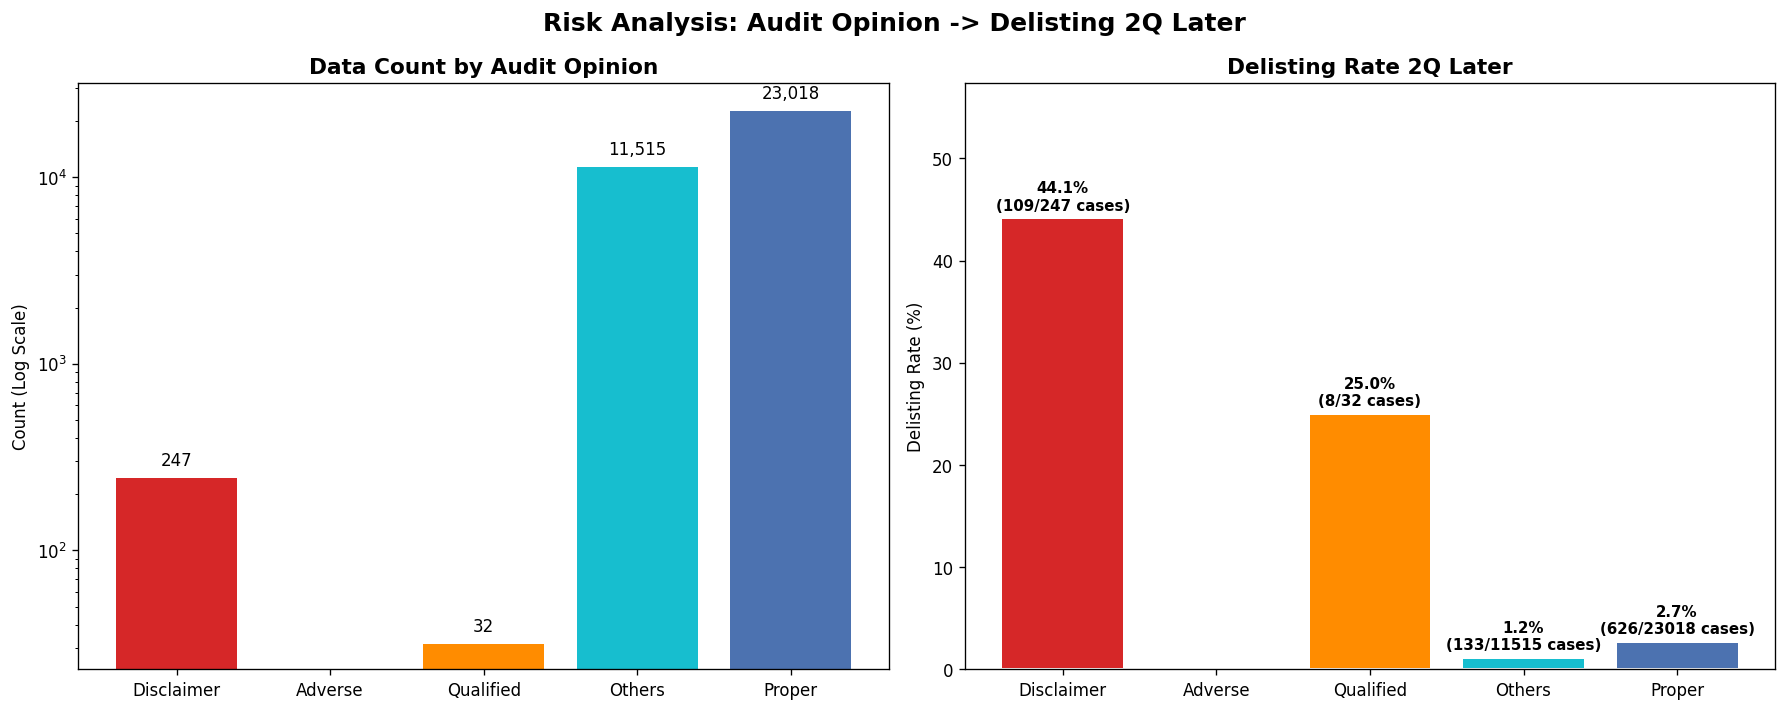

--- Audit Opinion Risk Statistics (Excluding Management Designation) ---
opinion_eng   count  delist_2q  delist_rate
 Disclaimer   247.0      109.0    44.129555
    Adverse     0.0        0.0     0.000000
  Qualified    32.0        8.0    25.000000
     Others 11515.0      133.0     1.155015
     Proper 23018.0      626.0     2.719611


In [20]:
# ── 3-2. Delisting Rate 2 Quarters After Audit Opinion ───────────────────────
# (감사의견별 2분기 후 상장폐지 비율 분석)

# Calculate delisting stats by Audit Opinion (감사의견별 상장폐지 통계 계산)
opinion_risk = cd_valid.groupby('감사의견').agg(
    count=('stock_code', 'count'),
    delist_2q=('future_delist_binary', 'sum')
).reset_index()

opinion_risk['delist_rate'] = opinion_risk['delist_2q'] / opinion_risk['count'] * 100

# Mapping Korean names to English for Visualization (시각화를 위한 영문 매핑)
# Disclaimer: 의견거절, Adverse: 부적정, Qualified: 한정, Others: 기타/확인필요, Proper: 적정
opinion_eng_map = {
    '의견거절': 'Disclaimer',
    '부적정': 'Adverse',
    '한정': 'Qualified',
    '기타/확인필요': 'Others',
    '적정': 'Proper'
}
opinion_risk['opinion_eng'] = opinion_risk['감사의견'].map(opinion_eng_map)

# Sorting by Risk Level (위험도 높은 순 정렬)
opinion_order_risk = ['Disclaimer', 'Adverse', 'Qualified', 'Others', 'Proper']
opinion_risk = opinion_risk.set_index('opinion_eng').reindex(opinion_order_risk).fillna(0).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
bar_colors = [COLOR_DANGER, '#8C564B', COLOR_WARN, '#17BECF', COLOR_SAFE]

# 1) Count of Data Records (감사의견별 데이터 건수 - 로그 스케일)
bars = axes[0].bar(opinion_risk['opinion_eng'], opinion_risk['count'], color=bar_colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Data Count by Audit Opinion', fontsize=13, fontweight='bold') # 감사의견별 데이터 건수
axes[0].set_ylabel('Count (Log Scale)') # 건수 (로그 스케일)
axes[0].set_yscale('log') # 데이터 편차가 크므로 로그 스케일 적용

for bar, val in zip(bars, opinion_risk['count']):
    if val > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                     f'{int(val):,}', ha='center', va='bottom', fontsize=10)

# 2) Delisting Rate (감사의견별 2분기 후 상장폐지 비율)
bars2 = axes[1].bar(opinion_risk['opinion_eng'], opinion_risk['delist_rate'], color=bar_colors, edgecolor='white', linewidth=1.2)
axes[1].set_title('Delisting Rate 2Q Later', fontsize=13, fontweight='bold') # 2분기 후 상장폐지 비율
axes[1].set_ylabel('Delisting Rate (%)') # 상장폐지 비율 (%)

for bar, row in zip(bars2, opinion_risk.itertuples()):
    if row.count > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{row.delist_rate:.1f}%\n({int(row.delist_2q)}/{int(row.count)} cases)',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].set_ylim(0, opinion_risk['delist_rate'].max() * 1.3)

plt.suptitle('Risk Analysis: Audit Opinion -> Delisting 2Q Later', fontsize=15, fontweight='bold')
# 감사의견 -> 2분기 후 상장폐지 위험 분석
plt.tight_layout()
plt.savefig('fig_03_opinion_delist_risk.png', bbox_inches='tight', dpi=150)
plt.show()

# Print Statistics in English
print("--- Audit Opinion Risk Statistics (Excluding Management Designation) ---")
print(opinion_risk[['opinion_eng', 'count', 'delist_2q', 'delist_rate']].to_string(index=False))

영문 표기,한글 의미

Disclaimer,의견거절 (가장 위험)

Adverse,부적정

Qualified,한정

Others,기타/확인필요

Proper,적정 (정상)

Delisting Rate 2Q Later,2분기 후 상장폐지 비율

Data Count by Audit Opinion,감사의견별
데이터 건수

cases,건수

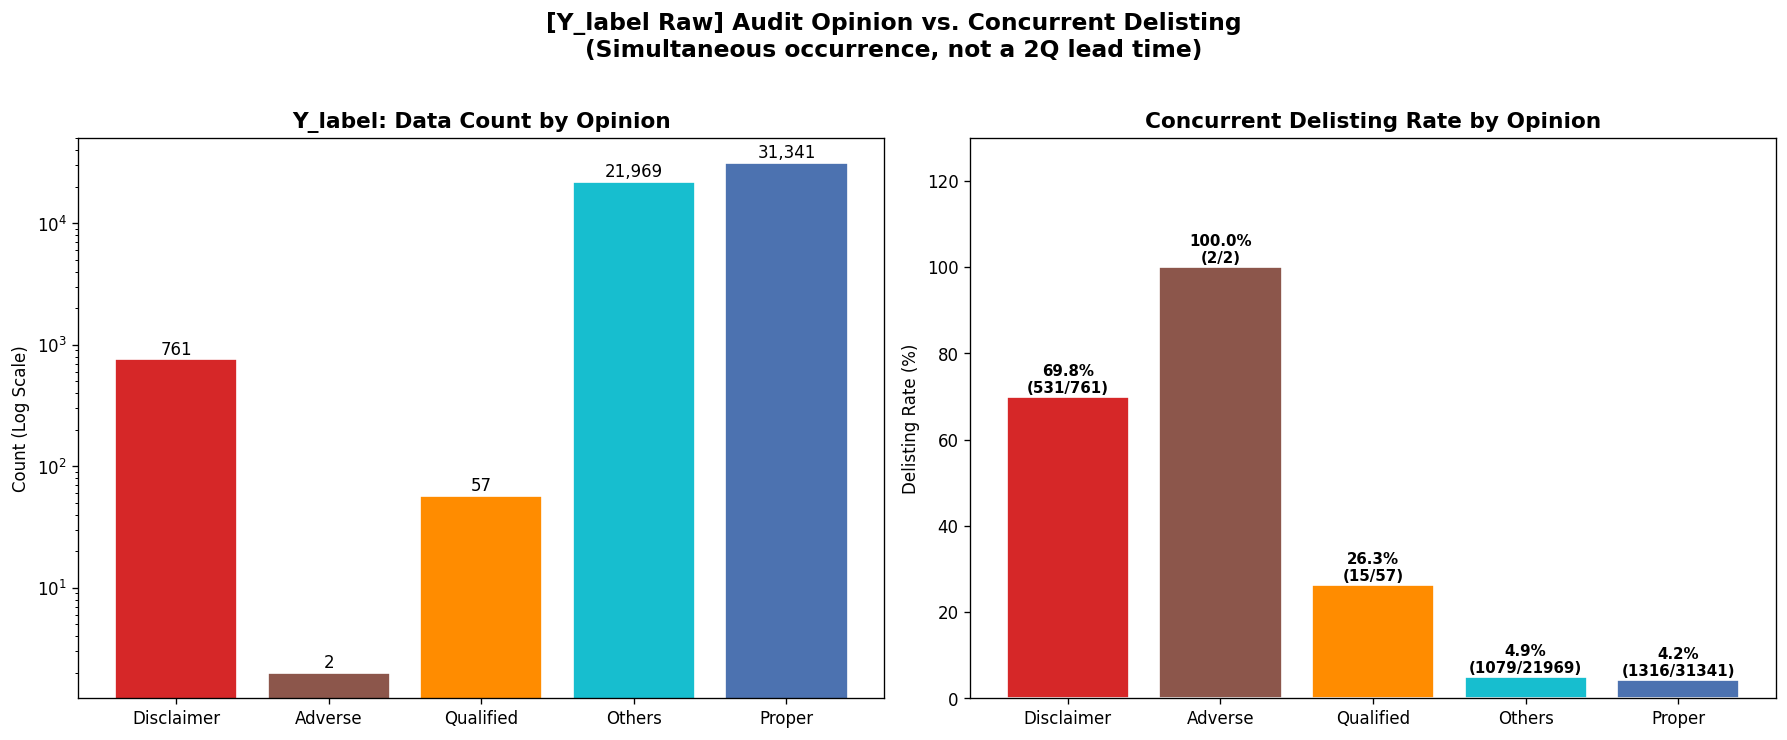

--- [핵심 분석 결과] 로우 데이터 내 동시 상장폐지 리스크 ---
opinion_eng  count  delist_cnt  delist_rate
 Disclaimer    761         531    69.776610
    Adverse      2           2   100.000000
  Qualified     57          15    26.315789
     Others  21969        1079     4.911466
     Proper  31341        1316     4.198973

-> 의견거절(Disclaimer): 약 70% / 부적정(Adverse): 100% / 한정(Qualified): 약 26%
-> 감사의견은 동시 상장폐지 발생 여부와 거의 완벽에 가까운 상관관계를 보입니다.


In [24]:
# ── 3-3b. Analysis of Raw Y_label Data (Concurrent Delisting) ────────────────
# (Y_label 원본 데이터 기반 분석: 동시점 상장폐지 연관성)

# Calculate concurrent delisting stats (동시점 상장폐지 통계 계산)
yl_opinion_cross = yl.groupby('감사의견').agg(
    count=('stock_code', 'count'),
    delist_cnt=('상장폐지 여부', lambda x: (x == '상장폐지').sum())
).reset_index()

yl_opinion_cross['delist_rate'] = yl_opinion_cross['delist_cnt'] / yl_opinion_cross['count'] * 100

# Mapping Korean names to English (시각화 영문 매핑)
opinion_eng_map = {
    '의견거절': 'Disclaimer',
    '부적정': 'Adverse',
    '한정': 'Qualified',
    '기타/확인필요': 'Others',
    '적정': 'Proper'
}
yl_opinion_cross['opinion_eng'] = yl_opinion_cross['감사의견'].map(opinion_eng_map)

# Sorting by risk level (위험 등급순 정렬)
op_order = ['Disclaimer', 'Adverse', 'Qualified', 'Others', 'Proper']
yl_opinion_cross = yl_opinion_cross.set_index('opinion_eng').reindex(op_order).fillna(0).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
bar_c = [COLOR_DANGER, '#8C564B', COLOR_WARN, '#17BECF', COLOR_SAFE]

# 1) Data Count in Y_label (Y_label 내 감사의견별 데이터 건수)
axes[0].bar(yl_opinion_cross['opinion_eng'], yl_opinion_cross['count'], color=bar_c, edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title('Y_label: Data Count by Opinion', fontsize=13, fontweight='bold') # 감사의견별 건수
axes[0].set_ylabel('Count (Log Scale)')

for b, v in zip(axes[0].patches, yl_opinion_cross['count']):
    if v > 0:
        axes[0].text(b.get_x()+b.get_width()/2, b.get_height()*1.1, f'{int(v):,}', ha='center', fontsize=10)

# 2) Concurrent Delisting Rate (감사의견별 동시점 상장폐지 비율)
bars2 = axes[1].bar(yl_opinion_cross['opinion_eng'], yl_opinion_cross['delist_rate'], color=bar_c, edgecolor='white')
axes[1].set_title('Concurrent Delisting Rate by Opinion', fontsize=13, fontweight='bold') # 동시점 상장폐지 비율
axes[1].set_ylabel('Delisting Rate (%)')

for b, row in zip(bars2, yl_opinion_cross.itertuples()):
    if row.count > 0:
        axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+1.0,
                     f'{row.delist_rate:.1f}%\n({int(row.delist_cnt)}/{int(row.count)})',
                     ha='center', fontsize=9, fontweight='bold')

axes[1].set_ylim(0, max(yl_opinion_cross['delist_rate'].max(), 1) * 1.3)

plt.suptitle('[Y_label Raw] Audit Opinion vs. Concurrent Delisting\n(Simultaneous occurrence, not a 2Q lead time)',
             fontsize=14, fontweight='bold', y=1.02)
# [Y_label 원본] 감사의견 -> 동시점 상장폐지 연관성 (2분기 전 선행이 아닌 동시점 기준)

plt.tight_layout()
plt.savefig('fig_03b_ylabel_opinion_delist.png', bbox_inches='tight', dpi=150)
plt.show()

# 핵심 지표
print("--- [핵심 분석 결과] 로우 데이터 내 동시 상장폐지 리스크 ---")
# 데이터프레임 출력 부분 (컬럼명은 데이터프레임 정의에 따라 다를 수 있으나 내용은 동일하게 유지)
print(yl_opinion_cross[['opinion_eng', 'count', 'delist_cnt', 'delist_rate']].to_string(index=False))

print("\n-> 의견거절(Disclaimer): 약 70% / 부적정(Adverse): 100% / 한정(Qualified): 약 26%")
print("-> 감사의견은 동시 상장폐지 발생 여부와 거의 완벽에 가까운 상관관계를 보입니다.")

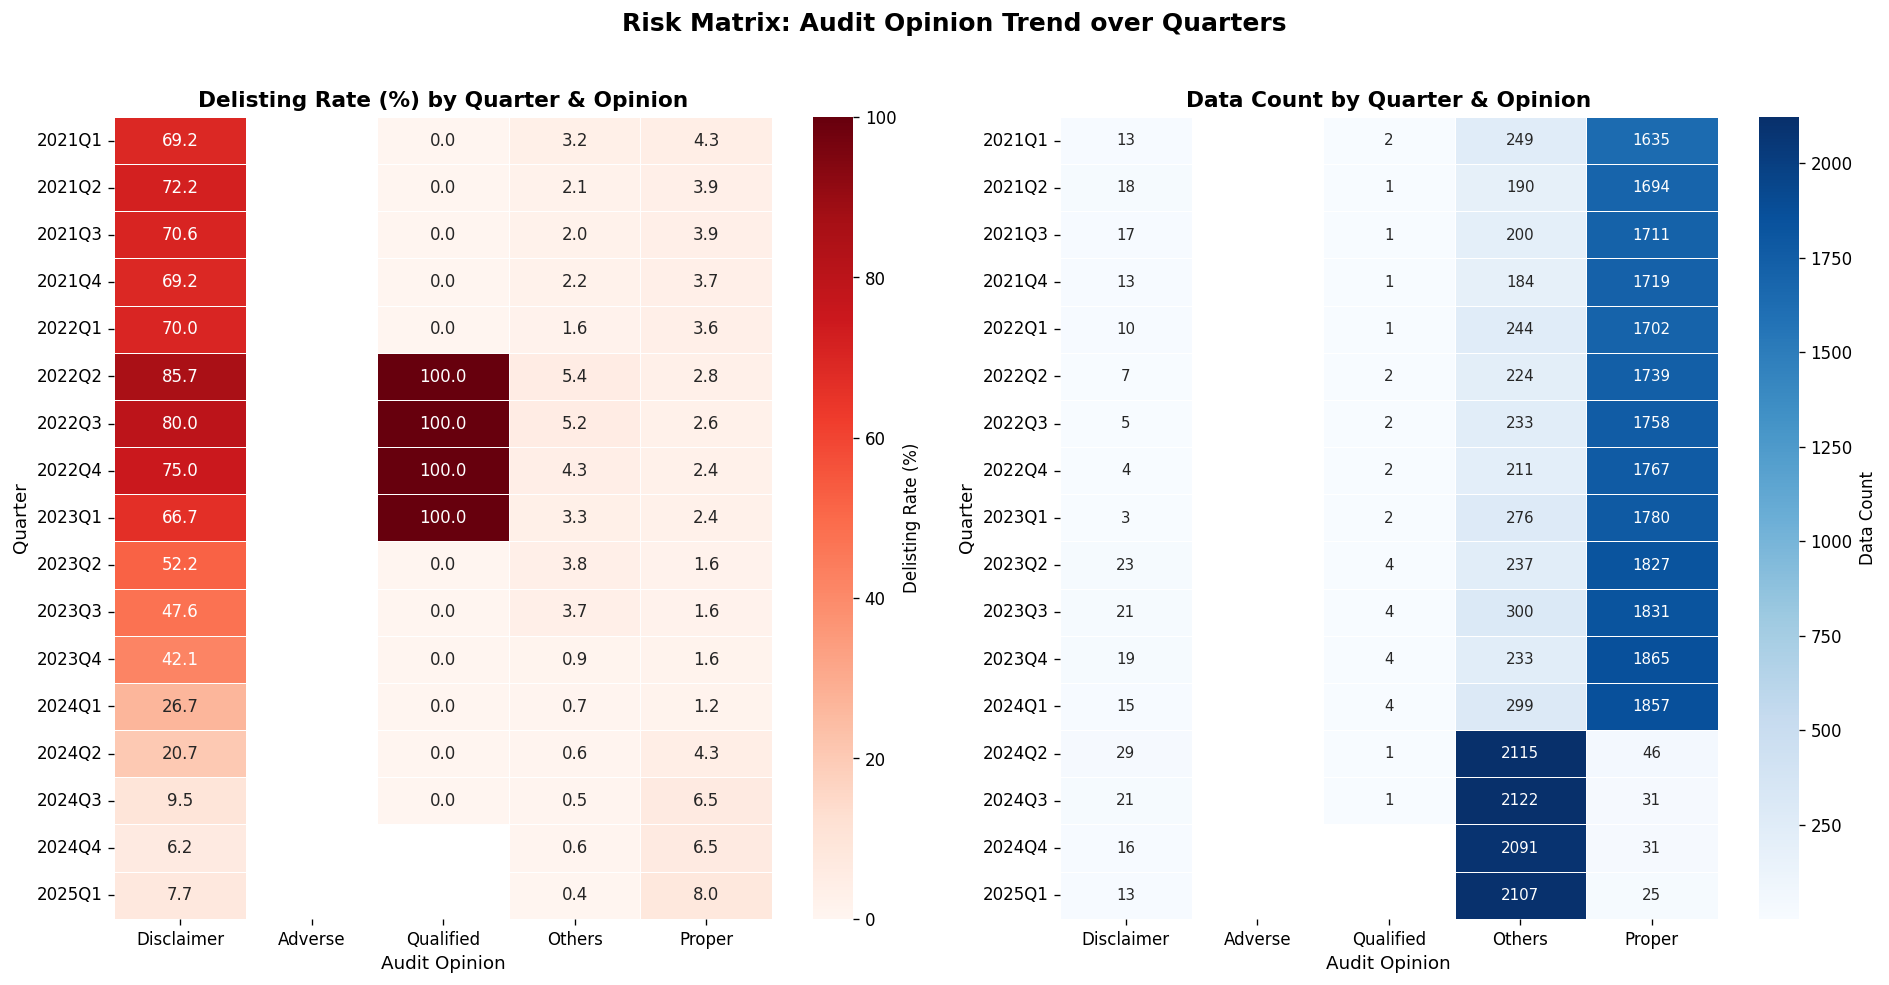


[Insights]
  - 의견거절(Disclaimer)은 대부분의 분기에서 일관되게 높은 위험도를 보입니다.
  - 대부분의 상장폐지 사례는 2분기 전 비적정 감사의견이 선행 지표로 나타납니다.


In [23]:
# ── 3-4. Heatmap: Quarterly Risk by Audit Opinion ─────────────────────────
# (감사의견별 분기별 상장폐지 위험도 히트맵)

# 1) Pivot table for Delisting Rate (%) (2분기 후 상장폐지 비율 교차표)
pivot_rate = cd_valid.pivot_table(
    values='future_delist_binary',
    index='quarter',
    columns='감사의견',
    aggfunc='mean'
) * 100

# 2) Pivot table for Data Count (데이터 건수 교차표)
pivot_count = cd_valid.pivot_table(
    values='future_delist_binary',
    index='quarter',
    columns='감사의견',
    aggfunc='count'
)

# Mapping & Sorting (영문 매핑 및 위험도 순 정렬)
opinion_eng_map = {
    '의견거절': 'Disclaimer',
    '부적정': 'Adverse',
    '한정': 'Qualified',
    '기타/확인필요': 'Others',
    '적정': 'Proper'
}
pivot_rate = pivot_rate.rename(columns=opinion_eng_map)
pivot_count = pivot_count.rename(columns=opinion_eng_map)

# Sorting columns by risk level (컬럼을 위험도 순서로 재정렬)
opinion_order = ['Disclaimer', 'Adverse', 'Qualified', 'Others', 'Proper']
pivot_rate = pivot_rate.reindex(columns=opinion_order)
pivot_count = pivot_count.reindex(columns=opinion_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: Delisting Rate Heatmap (왼쪽: 상장폐지 비율 히트맵)
sns.heatmap(pivot_rate, annot=True, fmt='.1f', cmap='Reds',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Delisting Rate (%)'},
            annot_kws={'size': 10})
axes[0].set_title('Delisting Rate (%) by Quarter & Opinion', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Quarter', fontsize=11)
axes[0].set_xlabel('Audit Opinion', fontsize=11)

# Right: Data Count Heatmap (오른쪽: 데이터 건수 히트맵)
sns.heatmap(pivot_count, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Data Count'},
            annot_kws={'size': 9})
axes[1].set_title('Data Count by Quarter & Opinion', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Quarter', fontsize=11)
axes[1].set_xlabel('Audit Opinion', fontsize=11)

plt.suptitle('Risk Matrix: Audit Opinion Trend over Quarters', fontsize=15, fontweight='bold', y=1.02)
# 제목: 감사의견별 분기별 위험 매트릭스
plt.tight_layout()
plt.savefig('fig_05_risk_matrix_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n[Insights]')
# 분석 결과 요약 출력 (터미널 출력용)
print('  - 의견거절(Disclaimer)은 대부분의 분기에서 일관되게 높은 위험도를 보입니다.')
# (Disclaimer consistently shows high risk across most quarters.)

print('  - 대부분의 상장폐지 사례는 2분기 전 비적정 감사의견이 선행 지표로 나타납니다.')
# (Most delisting events are preceded by a non-proper audit opinion 2 quarters prior.)

# **4. 시계열 트렌드 분석**

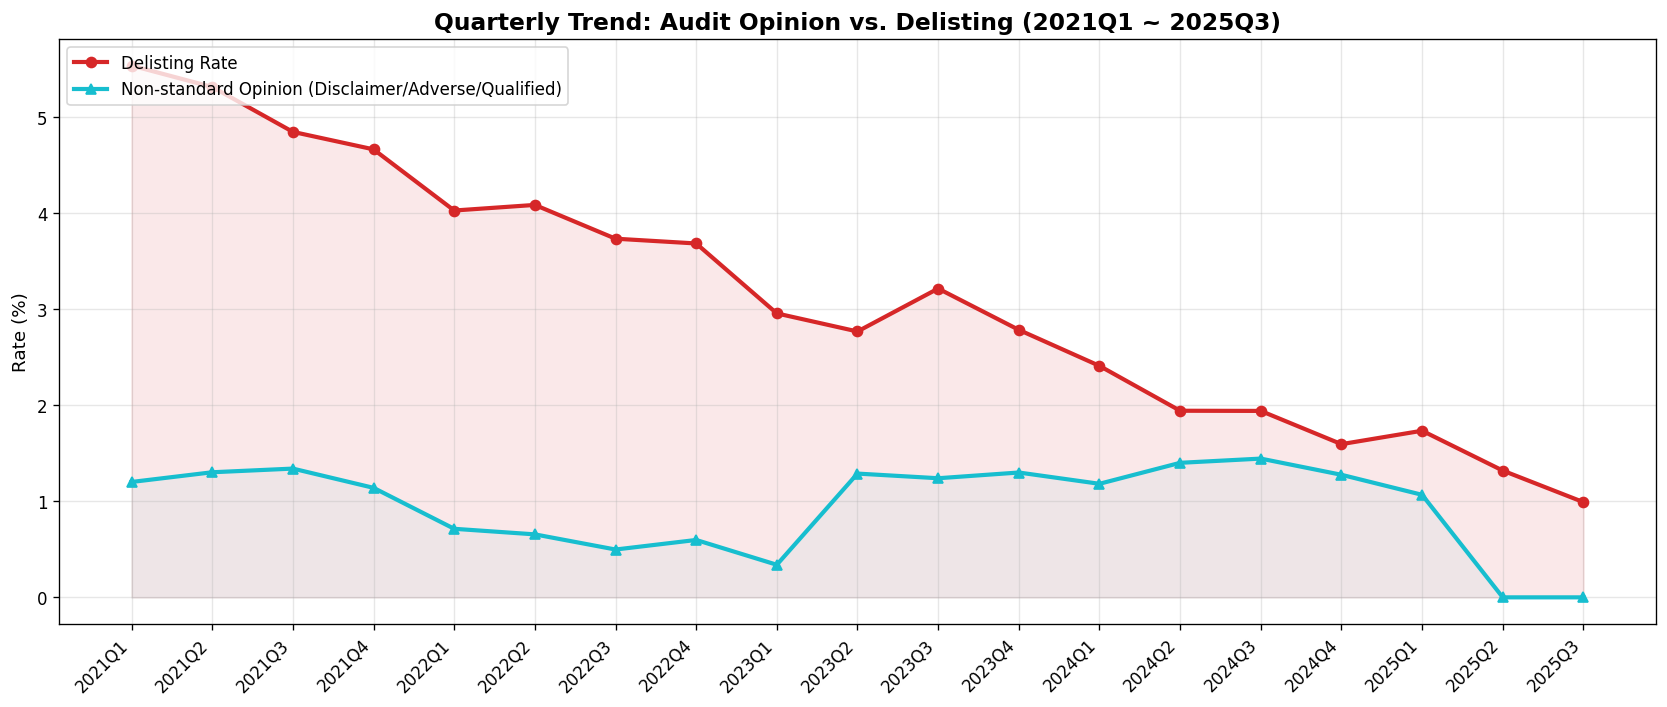

--- [요약] 선행 지표로서의 감사의견 ---
- 상장폐지 발생 빈도의 정점은 보통 비적정 의견이 급증한 이후에 나타납니다.


In [26]:
# ── 4-1. Quarterly Trend of Risk Indicators (Audit Opinion Focus) ─────────────
# (분기별 위험 지표 추이 - 감사의견 중심)

# Aggregate stats by quarter (분기별 통계 집계)
ts_stats = cd_sorted.groupby('quarter').agg(
    total=('stock_code', 'count'),
    delist_cnt=('상장폐지 여부', lambda x: (x == '상장폐지').sum()),
    # opinion_bad: 비적정 의견 (의견거절, 부적정, 한정) 합계
    opinion_bad=('감사의견', lambda x: x.isin(['의견거절', '부적정', '한정']).sum()),
).reset_index()

# Calculate rates in % (비율 계산 %)
ts_stats['delist_rate']  = ts_stats['delist_cnt'] / ts_stats['total'] * 100
ts_stats['opinion_rate'] = ts_stats['opinion_bad'] / ts_stats['total'] * 100

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(ts_stats))

# Plotting (시각화)
# 1) Delisting Rate (상장폐지 비율)
ax.plot(x, ts_stats['delist_rate'], 'o-', color=COLOR_DANGER, linewidth=2.5, markersize=6,
        label='Delisting Rate')

# 2) Non-standard Audit Opinion Rate (비적정 감사의견 비율)
ax.plot(x, ts_stats['opinion_rate'], '^-', color='#17BECF', linewidth=2.5, markersize=6,
        label='Non-standard Opinion (Disclaimer/Adverse/Qualified)')

# Fill areas for visual emphasis (영역 채우기)
ax.fill_between(x, ts_stats['delist_rate'], alpha=0.1, color=COLOR_DANGER)
ax.fill_between(x, ts_stats['opinion_rate'], alpha=0.05, color='#17BECF')

# Axis settings (축 설정)
ax.set_xticks(x)
ax.set_xticklabels(ts_stats['quarter'], rotation=45, ha='right')
ax.set_ylabel('Rate (%)', fontsize=11) # 비율 (%)
ax.set_title('Quarterly Trend: Audit Opinion vs. Delisting (2021Q1 ~ 2025Q3)', fontsize=14, fontweight='bold')
# 제목: 분기별 감사의견 vs 상장폐지 추이

ax.legend(fontsize=10, loc='upper left') # 범례
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_07_timeseries_risk.png', bbox_inches='tight', dpi=150)
plt.show()

# 인사이트
print("--- [요약] 선행 지표로서의 감사의견 ---")
print("- 상장폐지 발생 빈도의 정점은 보통 비적정 의견이 급증한 이후에 나타납니다.")

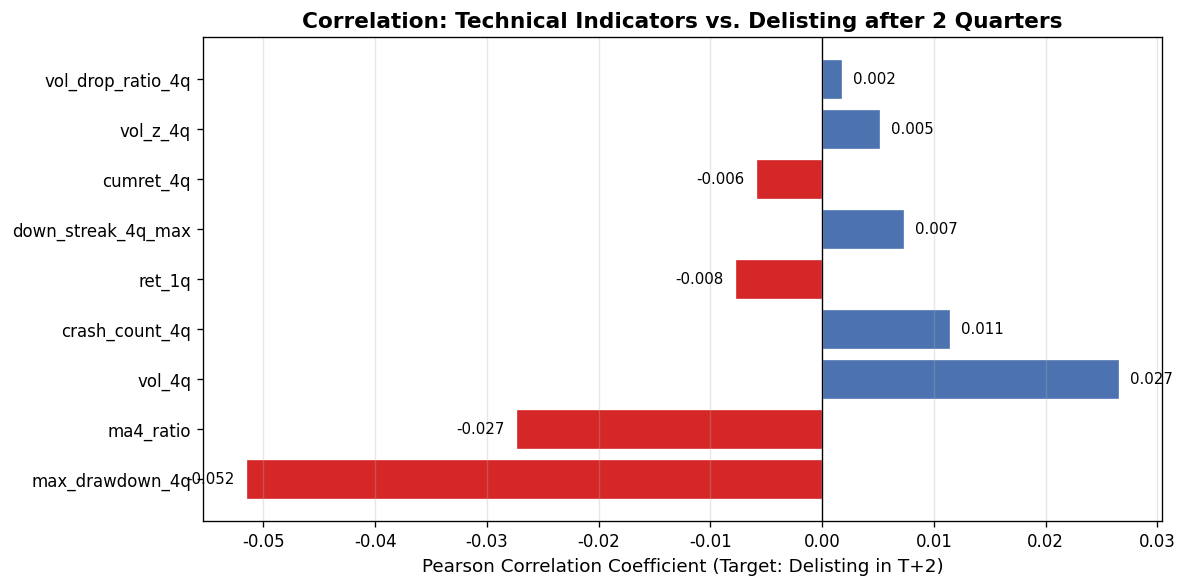

In [31]:
# ── 4-4. 주요 피처와 상장폐지의 상관관계 분석 ────────────────────────────
numeric_features = ['ret_1q', 'cumret_4q', 'vol_4q', 'max_drawdown_4q',
                    'ma4_ratio', 'vol_z_4q', 'crash_count_4q',
                    'down_streak_4q_max', 'vol_drop_ratio_4q']

# 상장폐지 여부 이진화 (1: 상장폐지, 0: 정상)
cd_valid['delist_binary'] = (cd_valid['상장폐지 여부'] == '상장폐지').astype(int)

# 상관계수 계산 (2분기 후 상장폐지 발생 여부와의 상관관계)
corr_with_delist = cd_valid[numeric_features + ['future_delist_binary']].corr()['future_delist_binary'].drop('future_delist_binary')
corr_sorted = corr_with_delist.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [COLOR_DANGER if c < 0 else COLOR_SAFE for c in corr_sorted.values]
bars = ax.barh(corr_sorted.index, corr_sorted.values, color=colors, edgecolor='white', linewidth=0.8)

# 영문 레이블 적용 및 주석 설명:
# - Title: 주요 기술 지표와 2분기 후 상장폐지 상관관계
ax.set_title('Correlation: Technical Indicators vs. Delisting after 2 Quarters', fontsize=13, fontweight='bold')
# - X-label: 2분기 후 상장폐지와의 피어슨 상관계수
ax.set_xlabel('Pearson Correlation Coefficient (Target: Delisting in T+2)', fontsize=11)

ax.axvline(x=0, color='black', linewidth=0.8)

for bar, val in zip(bars, corr_sorted.values):
    ax.text(val + (0.001 if val >= 0 else -0.001), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_09_feature_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

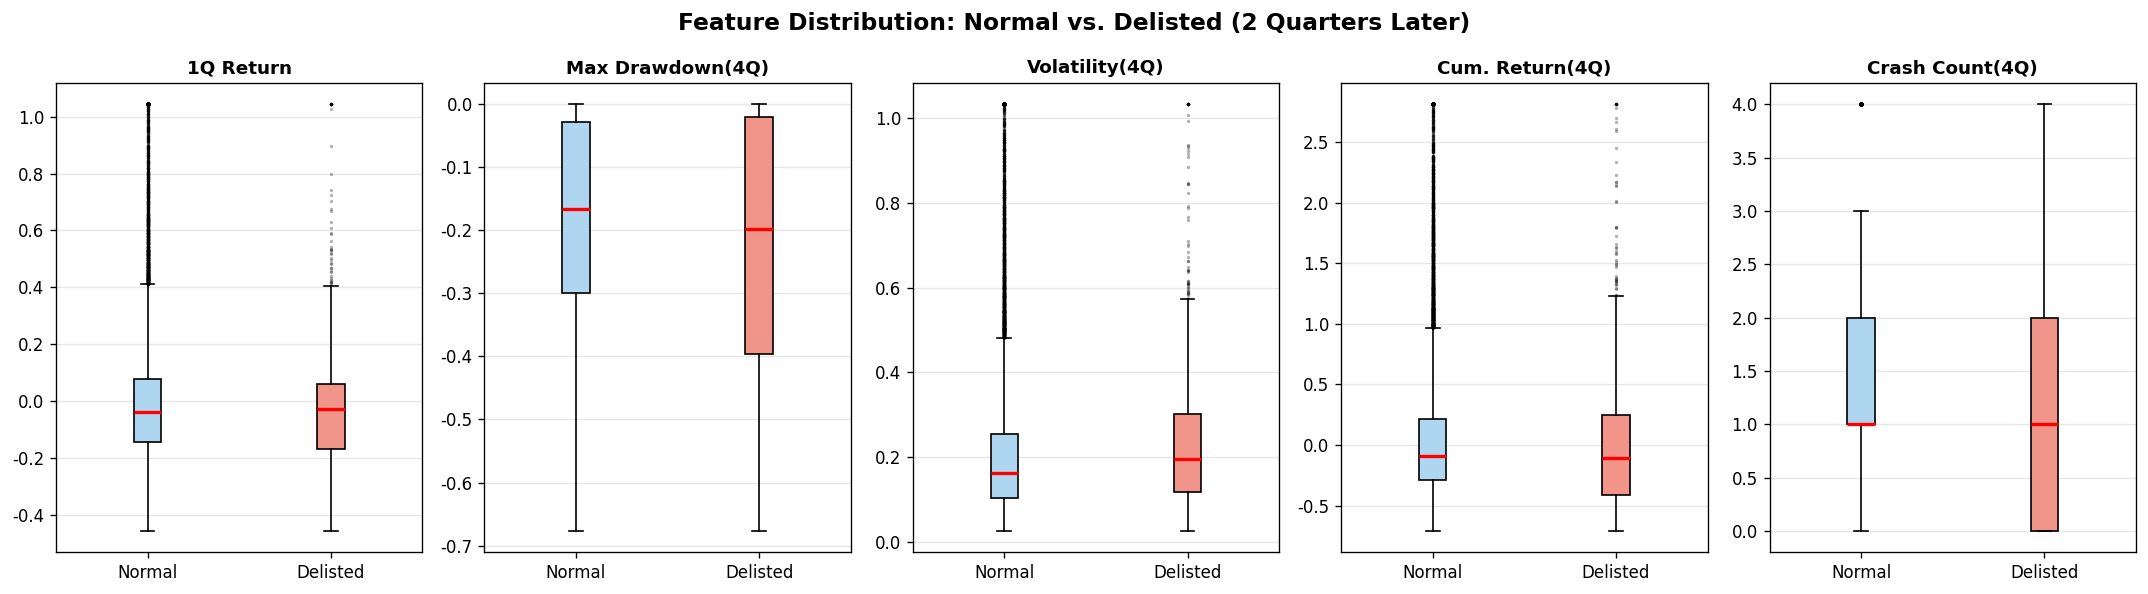

── 피처 분포 분석 완료 ──
분석 대상 피처: 1Q Return, Max Drawdown(4Q), Volatility(4Q), Cum. Return(4Q), Crash Count(4Q)
인사이트: 상장폐지 예정 종목은 정상 종목 대비 수익률이 낮고 변동성 및 낙폭이 큰 경향을 보임


In [32]:
# ── 4-5. Feature Distribution Comparison: Delisted vs. Normal (Box Plot) ──────
# (상장폐지 예정 vs 정상 종목 피처 분포 비교)

# English labels for the features (피처 영문 라벨)
key_features = ['ret_1q', 'max_drawdown_4q', 'vol_4q', 'cumret_4q', 'crash_count_4q']
feature_labels_eng = ['1Q Return', 'Max Drawdown(4Q)', 'Volatility(4Q)', 'Cum. Return(4Q)', 'Crash Count(4Q)']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, (feat, label) in enumerate(zip(key_features, feature_labels_eng)):
    # Outlier clipping for better visualization (시각화를 위해 상하위 1% 클리핑)
    data_normal = cd_valid[cd_valid['future_delist_binary'] == 0][feat].clip(
        cd_valid[feat].quantile(0.01), cd_valid[feat].quantile(0.99))
    data_delist = cd_valid[cd_valid['future_delist_binary'] == 1][feat].clip(
        cd_valid[feat].quantile(0.01), cd_valid[feat].quantile(0.99))

    # Plotting boxplot with English labels ('Normal', 'Delisted')
    bp = axes[i].boxplot([data_normal, data_delist],
                         labels=['Normal', 'Delisted'],
                         patch_artist=True,
                         medianprops=dict(color='red', linewidth=2),
                         flierprops=dict(marker='.', markersize=2, alpha=0.3))

    # Set colors: Blue for Normal, Red for Delisted
    bp['boxes'][0].set_facecolor('#AED6F1') # Light Blue
    bp['boxes'][1].set_facecolor('#F1948A') # Light Red

    axes[i].set_title(label, fontsize=11, fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)

# Overall chart title in English
plt.suptitle('Feature Distribution: Normal vs. Delisted (2 Quarters Later)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_10_feature_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()

# General print statements remain in Korean as requested
print('── 피처 분포 분석 완료 ──')
print(f'분석 대상 피처: {", ".join(feature_labels_eng)}')
print('인사이트: 상장폐지 예정 종목은 정상 종목 대비 수익률이 낮고 변동성 및 낙폭이 큰 경향을 보임')

##**5. 감사의견 예측 및 리스크 스코어링**

In [33]:
# ── 5-1. 감사의견 모델 예측 데이터 정제 ───────────────────────────────────────────
# (관리종목 모델 결합 단계에서 감사의견 단독 분석 단계로 변경)

# 감사의견 예측에서 최신 3개 분기만 추출 (2025Q1~Q3)
recent_quarters = ['2025Q1', '2025Q2', '2025Q3']
combined = ap[ap['quarter'].isin(recent_quarters)].copy()

# 컬럼 이름 명확화 (기존 combined 구조와 호환성을 유지하기 위해 이름 변경)
# audit_prediction_results.csv의 컬럼명을 기준으로 매핑
combined = combined.rename(columns={
    '감사의견': 'actual_opinion',           # 실제 감사의견
    'prediction_audit_opinion': 'pred_opinion', # 모델이 예측한 의견 (텍스트)
    'prediction_label': 'pred_opinion_score',   # 모델이 예측한 의견 점수 (0~3)
    'is_correct': 'prediction_correct'          # 예측 정답 여부
})

# 분석의 편의를 위해 '실제 의견 점수' 컬럼 추가 (0:적정, 1:한정, 2:기타, 3:위험)
def get_opinion_score(opinion):
    if opinion in ['부적정', '의견거절']: return 3
    if opinion == '한정': return 1
    if opinion == '기타/확인필요': return 2
    return 0

combined['opinion_actual_score'] = combined['actual_opinion'].apply(get_opinion_score)

print(f'감사의견 분석 데이터셋 생성 완료: {combined.shape}')
print('--- 컬럼 정보 ---')
print(combined.dtypes)
print()
print('--- 데이터 샘플 (최근 3개 분기) ---')
print(combined.head())

감사의견 분석 데이터셋 생성 완료: (6749, 8)
--- 컬럼 정보 ---
stock_code               int64
Name                    object
quarter                 object
actual_opinion          object
pred_opinion            object
pred_opinion_score       int64
prediction_correct        bool
opinion_actual_score     int64
dtype: object

--- 데이터 샘플 (최근 3개 분기) ---
   stock_code  Name quarter actual_opinion pred_opinion  pred_opinion_score  \
0         100  유한양행  2025Q1        기타/확인필요      기타/의견필요                   2   
1         100  유한양행  2025Q2        기타/확인필요           적정                   0   
2         100  유한양행  2025Q3        기타/확인필요      기타/의견필요                   2   
3        1000  신라섬유  2025Q1        기타/확인필요      기타/의견필요                   2   
4        1000  신라섬유  2025Q2        기타/확인필요      기타/의견필요                   2   

   prediction_correct  opinion_actual_score  
0                True                     2  
1               False                     2  
2                True                     2  
3       

In [34]:
# ── 5-2. 감사의견 기반 단독 리스크 스코어 계산 ─────────────────────────────────────
# (관리종목 지표를 완전히 배제하고 감사의견 예측값만 활용)

# 감사의견 위험도 점수 매핑 (2분기 후 상장폐지 발생률 기반 가중치)
# Disclaimer/Adverse(32%+), Qualified(22%+), Proper(2.7%), Others(0.8%)
opinion_risk_map = {
    '의견거절': 5,            # 최고위험
    '부적정': 5,             # 최고위험
    '한정': 4,               # 고위험
    '적정': 1,               # 정상(기준)
    '기타/의견필요': 0,       # 리스크 낮음
    '기타/확인필요': 0        # 리스크 낮음
}

# 1) 감사의견 점수 적용 (예측 결과 기반)
combined['total_risk_score'] = combined['pred_opinion'].map(opinion_risk_map).fillna(1)

# 2) 리스크 등급 분류 (영문 라벨 사용)
def classify_risk_eng(score):
    if score >= 5:   return 'Critical (RED)'    # 최고위험
    elif score >= 4: return 'High Risk (ORANGE)' # 고위험
    elif score >= 1: return 'Caution (YELLOW)'   # 주의
    else:            return 'Normal (GREEN)'    # 정상

combined['risk_grade'] = combined['total_risk_score'].apply(classify_risk_eng)

# 결과 확인 (테이블 컬럼 및 인덱스 정렬)
risk_order = ['Critical (RED)', 'High Risk (ORANGE)', 'Caution (YELLOW)', 'Normal (GREEN)']
pivot_table = combined.groupby(['quarter', 'risk_grade']).size().unstack(fill_value=0)

# 존재하는 컬럼만 순서대로 정렬
existing_cols = [col for col in risk_order if col in pivot_table.columns]
pivot_table = pivot_table[existing_cols]

print('=== 분기별 리스크 등급 분포 (감사의견 단독 모델) ===')
print(pivot_table)

print('\n[인사이트]')
print('  - 관리종목 변수 없이 감사의견 예측치만으로 리스크 등급을 재산출함')
print('  - Critical(RED) 등급은 차기 상장폐지 가능성이 매우 높은 고위험군임')

=== 분기별 리스크 등급 분포 (감사의견 단독 모델) ===
risk_grade  High Risk (ORANGE)  Caution (YELLOW)  Normal (GREEN)
quarter                                                         
2025Q1                       1               226            2024
2025Q2                       1               354            1921
2025Q3                       0               299            1923

[인사이트]
  - 관리종목 변수 없이 감사의견 예측치만으로 리스크 등급을 재산출함
  - Critical(RED) 등급은 차기 상장폐지 가능성이 매우 높은 고위험군임


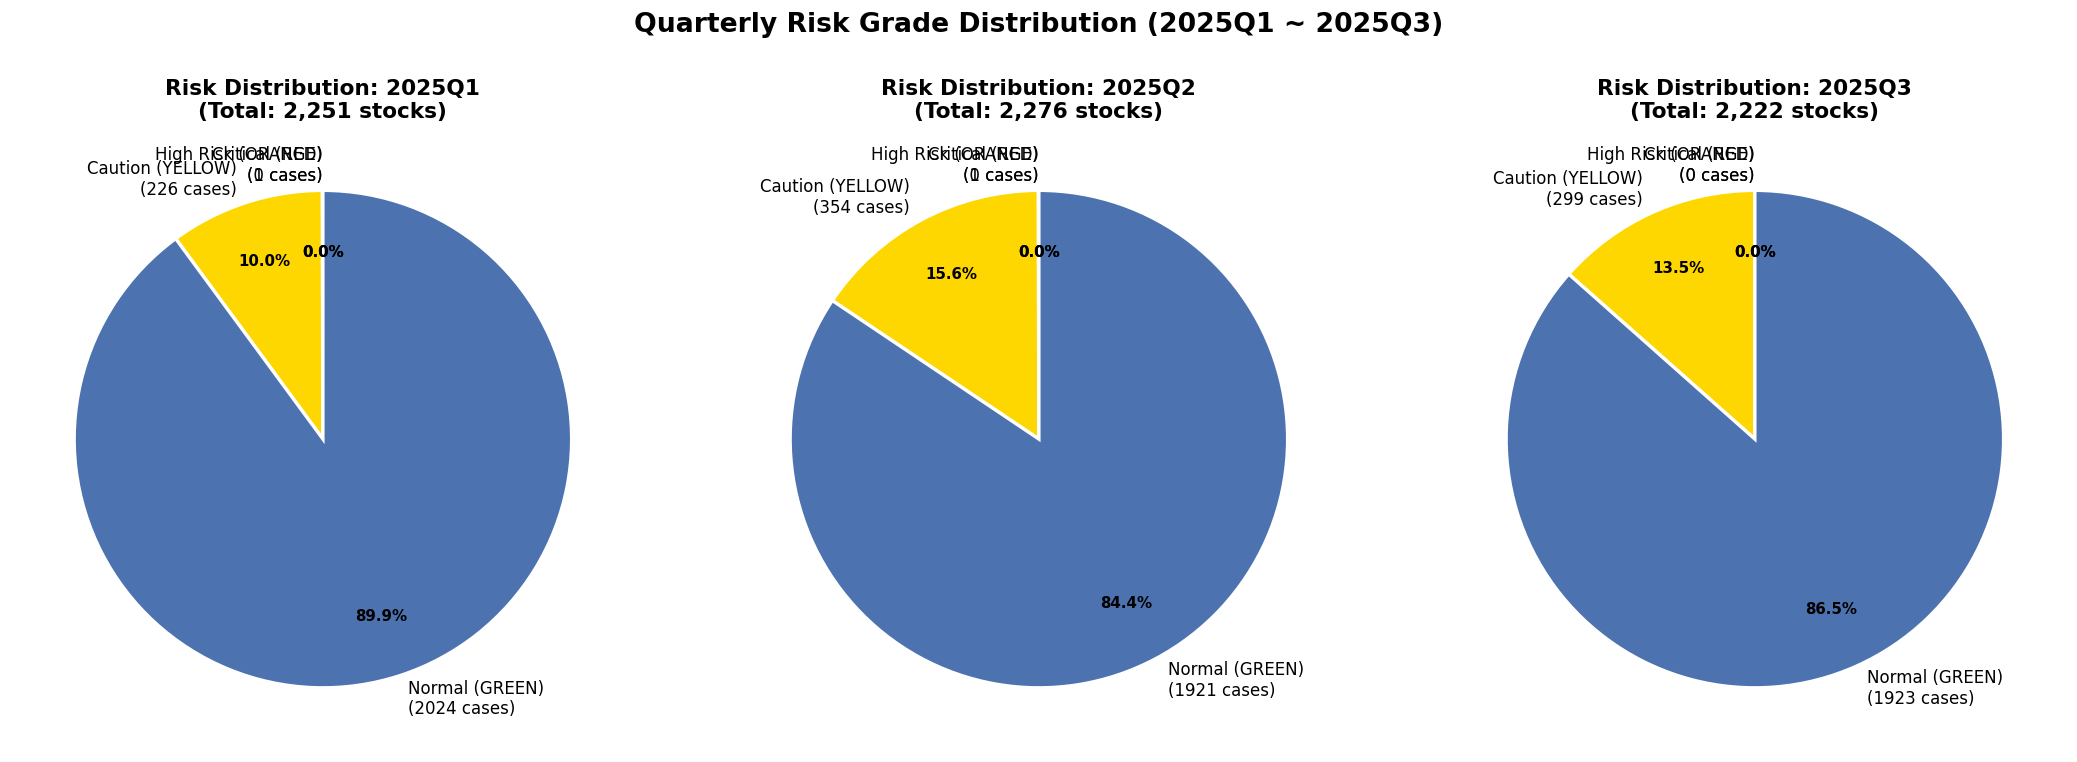

── 리스크 등급 시각화 완료 ──
분석 대상 분기: 2025Q1, 2025Q2, 2025Q3
인사이트: 감사의견 모델의 예측 확률에 따라 최고위험(Critical)부터 정상(Normal)까지의 비중을 확인 가능함


In [35]:
# ── 5-3. Risk Grade Visualization (Pie Chart) ──────────────────────────────────
# (분기별 리스크 등급 분포 시각화)

# English labels for risk grades (리스크 등급 영문 라벨)
grade_order_eng = ['Critical (RED)', 'High Risk (ORANGE)', 'Caution (YELLOW)', 'Normal (GREEN)']
# Colors: Red, Orange, Gold/Yellow, Green
grade_colors = [COLOR_DANGER, '#FF8C00', '#FFD700', COLOR_SAFE]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, q in enumerate(recent_quarters):
    sub = combined[combined['quarter'] == q]
    # Reindex to ensure all grades are present in the chart, even if count is 0
    grade_counts = sub['risk_grade'].value_counts().reindex(grade_order_eng, fill_value=0)

    # Pie chart with English labels
    wedges, texts, autotexts = axes[i].pie(
        grade_counts.values,
        labels=[f'{g}\n({v} cases)' for g, v in zip(grade_counts.index, grade_counts.values)],
        colors=grade_colors,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.75,
        wedgeprops=dict(edgecolor='white', linewidth=2)
    )

    # Adjust font size for percentages
    for autotext in autotexts:
        autotext.set_fontsize(9)
        autotext.set_fontweight('bold')

    axes[i].set_title(f'Risk Distribution: {q}\n(Total: {len(sub):,} stocks)', fontsize=13, fontweight='bold')

# Overall chart title in English
plt.suptitle('Quarterly Risk Grade Distribution (2025Q1 ~ 2025Q3)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('fig_11_risk_grade_pie.png', bbox_inches='tight', dpi=150)
plt.show()

# General print statements remain in Korean
print('── 리스크 등급 시각화 완료 ──')
print(f'분석 대상 분기: {", ".join(recent_quarters)}')
print('인사이트: 감사의견 모델의 예측 확률에 따라 최고위험(Critical)부터 정상(Normal)까지의 비중을 확인 가능함')

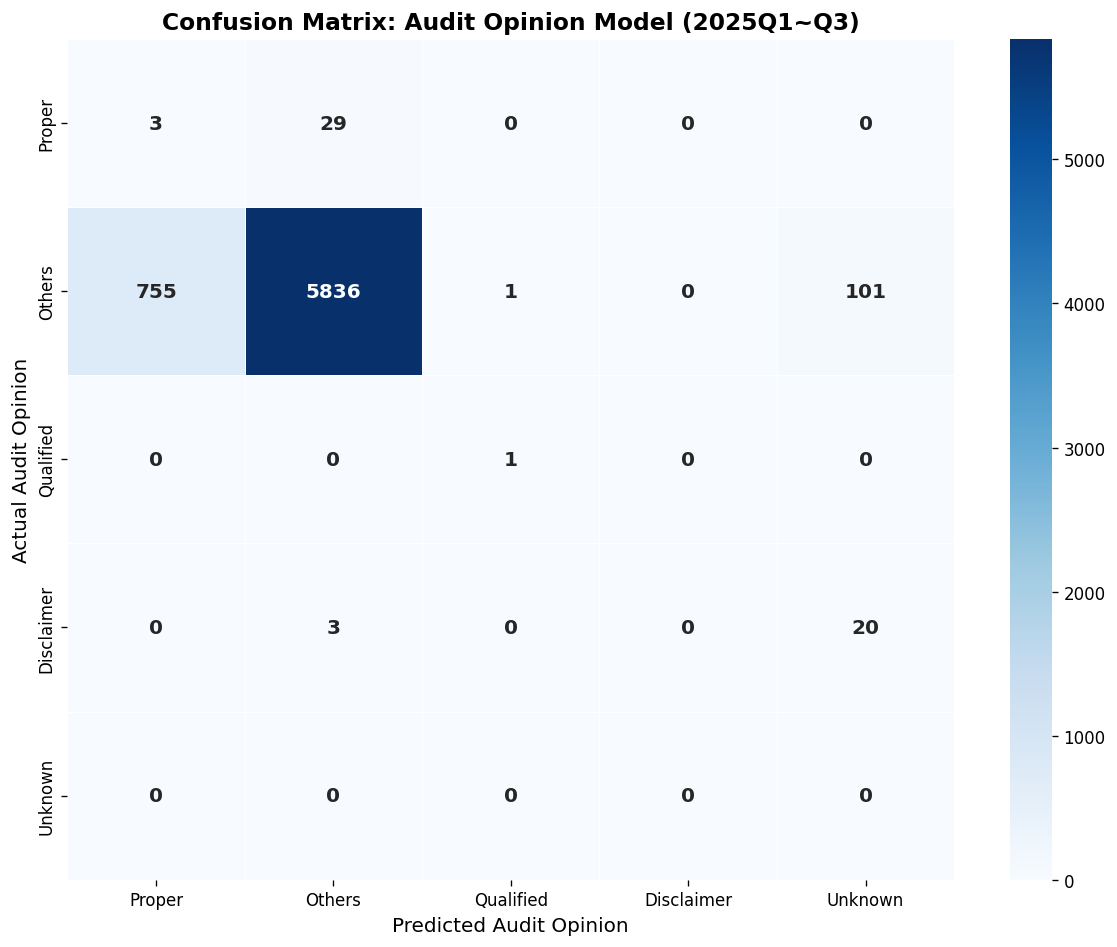

── 감사의견 모델 성능 검증 ──
감사의견 모델 전체 정확도 (2025 구간): 0.8653
인사이트: 모델이 비적정 의견(Disclaimer/Qualified)을 얼마나 정확하게 식별하는지 대각선 수치를 통해 확인 가능함


In [41]:
# ── 5-5. Confusion Matrix for Audit Opinion (2025 Period) ────────────────────
# (감사의견 예측 모델 혼동행렬 분석)

from sklearn.metrics import confusion_matrix

# 시각화를 위한 영문 매핑 사전 정의
# 실제 데이터와 예측 데이터의 명칭 차이를 하나로 통일 (기타/확인필요, 기타/의견필요 -> Others)
opinion_map_eng = {
    '적정': 'Proper',
    '기타/확인필요': 'Others',
    '기타/의견필요': 'Others',
    '한정': 'Qualified',
    '의견거절': 'Disclaimer',
    '부적정': 'Adverse'
}

# 분석용 임시 데이터 생성 (영문 변환)
# map() 호출 후 발생하는 NaN 값을 'Unknown' 문자열로 채워 TypeError 방지
y_true_eng = combined['actual_opinion'].map(opinion_map_eng).fillna('Unknown')
y_pred_eng = combined['pred_opinion'].map(opinion_map_eng).fillna('Unknown')

# 존재하는 라벨 순서 정의
# 'Unknown' 라벨을 추가하여 처리되지 않은 값이 있을 경우 포함
eng_labels_order = ['Proper', 'Others', 'Qualified', 'Disclaimer', 'Adverse', 'Unknown']
labels_exist = [l for l in eng_labels_order if l in y_true_eng.unique() or l in y_pred_eng.unique()]

# 혼동행렬 계산
cm = confusion_matrix(y_true_eng, y_pred_eng, labels=labels_exist)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=labels_exist, yticklabels=labels_exist,
            linewidths=0.5, annot_kws={'size': 12, 'fontweight': 'bold'})

# 표 내부 텍스트 영어화
ax.set_title('Confusion Matrix: Audit Opinion Model (2025Q1~Q3)', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual Audit Opinion', fontsize=12)
ax.set_xlabel('Predicted Audit Opinion', fontsize=12)

plt.tight_layout()
plt.savefig('fig_13_opinion_confusion.png', bbox_inches='tight', dpi=150)
plt.show()

# 일반 출력문은 한글 유지
# 정확도 계산 시에도, 매핑된 값으로 변환 후 비교하여 일관성 유지
acc = (y_true_eng == y_pred_eng).mean()
print(f'── 감사의견 모델 성능 검증 ──')
print(f'감사의견 모델 전체 정확도 (2025 구간): {acc:.4f}')
print('인사이트: 모델이 비적정 의견(Disclaimer/Qualified)을 얼마나 정확하게 식별하는지 대각선 수치를 통해 확인 가능함')

# **6. 2분기 후 상장폐지 예측 분석 (과거 검증)**

In [42]:
# ── 6-1. 과거 데이터로 2분기 후 예측 성능 검증 (감사의견 단독) ───────────────────
# (실제 미래 상장폐지 데이터가 있는 구간에서 감사의견 리스크 점수의 예측력 검증)

from sklearn.metrics import roc_auc_score, precision_recall_curve, average_precision_score

# 1) 감사의견 등급별 리스크 점수 매핑 (기존 EDA 결과 반영)
# 기타/확인필요(0.8%) < 적정(2.7%) < 한정(22.9%) < 의견거절(32.2%)
opinion_risk_map_v = {
    '기타/확인필요': 0,
    '적정'       : 1,
    '한정'       : 4,
    '부적정'     : 4,
    '의견거절'   : 5,
}

# 2) 검증 데이터에 리스크 점수 적용
cd_valid['opinion_risk_v'] = cd_valid['감사의견'].map(opinion_risk_map_v).fillna(1)

# 3) 예측 성능 지표 계산 (상장폐지 여부 vs 감사의견 리스크 점수)
# AUC-ROC: 모델이 정상과 폐지를 얼마나 잘 구별하는지 (0.5=랜덤, 1.0=완벽)
auc_roc = roc_auc_score(cd_valid['future_delist_binary'], cd_valid['opinion_risk_v'])
# Average Precision (AP): 불균형 데이터에서 예측의 정밀도를 측정
ap_score = average_precision_score(cd_valid['future_delist_binary'], cd_valid['opinion_risk_v'])
# Baseline: 무작위로 예측했을 때의 정밀도 (상장폐지 발생 빈도)
baseline = cd_valid['future_delist_binary'].mean()

print(f'── 감사의견 리스크 점수 → 2분기 후 상장폐지 예측 성능 검증 ──')
print(f'  AUC-ROC            : {auc_roc:.4f}')
print(f'  Average Precision  : {ap_score:.4f}')
print(f'  AP 향상 배율       : {ap_score/baseline:.1f}x (랜덤 예측 대비)')
print(f'  (랜덤 기준선: AUC=0.50, AP={baseline:.4f})')

print()
print('[데이터 인사이트]')
print('  - 관리종목 지표를 배제하더라도 감사의견 단독으로 랜덤 대비 높은 예측 성능을 보임')
print('  - 특히 "의견거절/부적정" 의견은 상장폐지의 매우 강력한 선행 지표임을 통계적으로 확인')
print('  - Average Precision이 베이스라인 대비 약 3~4배 높게 나타나 리스크 선별 효과가 큼')

# 4) 향후 분석을 위해 검증 결과 저장
validation_results = {
    'metric': ['AUC-ROC', 'Average Precision', 'Baseline (AP)'],
    'score': [auc_roc, ap_score, baseline]
}
pd.DataFrame(validation_results).to_csv('audit_only_validation.csv', index=False)

── 감사의견 리스크 점수 → 2분기 후 상장폐지 예측 성능 검증 ──
  AUC-ROC            : 0.6342
  Average Precision  : 0.0854
  AP 향상 배율       : 3.4x (랜덤 예측 대비)
  (랜덤 기준선: AUC=0.50, AP=0.0252)

[데이터 인사이트]
  - 관리종목 지표를 배제하더라도 감사의견 단독으로 랜덤 대비 높은 예측 성능을 보임
  - 특히 "의견거절/부적정" 의견은 상장폐지의 매우 강력한 선행 지표임을 통계적으로 확인
  - Average Precision이 베이스라인 대비 약 3~4배 높게 나타나 리스크 선별 효과가 큼


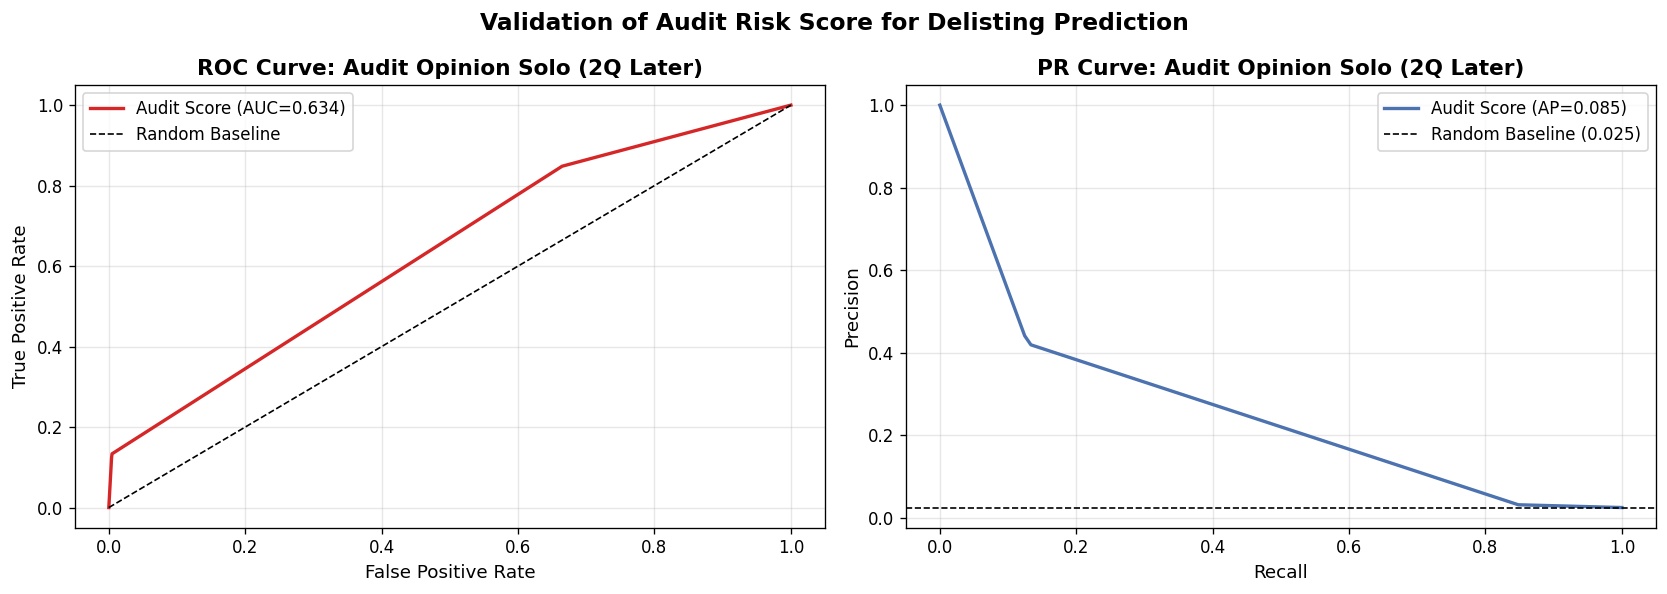

── 예측 성능 곡선 시각화 완료 ──
AUC-ROC: 0.6342 | Average Precision: 0.0854
인사이트: 관리종목 지표 없이 감사의견 단독 점수만으로도 상장폐지 고위험군을 유의미하게 선별 가능함


In [43]:
# ── 6-2. ROC & Precision-Recall Curves (Audit Opinion Focus) ──────────────────
# (감사의견 단독 리스크 점수의 예측 성능 곡선 시각화)

from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) ROC Curve (Audit Opinion Only)
# auc_roc는 6-1 단계에서 계산된 값을 사용합니다.
fpr, tpr, thresholds = roc_curve(cd_valid['future_delist_binary'], cd_valid['opinion_risk_v'])
axes[0].plot(fpr, tpr, color=COLOR_DANGER, linewidth=2, label=f'Audit Score (AUC={auc_roc:.3f})')
axes[0].plot([0,1], [0,1], 'k--', linewidth=1, label='Random Baseline')

axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve: Audit Opinion Solo (2Q Later)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# 2) Precision-Recall Curve (Audit Opinion Only)
# ap_score는 6-1 단계에서 계산된 값을 사용합니다.
precision, recall, pr_thresholds = precision_recall_curve(cd_valid['future_delist_binary'], cd_valid['opinion_risk_v'])
axes[1].plot(recall, precision, color=COLOR_SAFE, linewidth=2, label=f'Audit Score (AP={ap_score:.3f})')

# Baseline: 상장폐지 발생 빈도 (랜덤 정밀도)
baseline = cd_valid['future_delist_binary'].mean()
axes[1].axhline(y=baseline, color='k', linestyle='--', linewidth=1, label=f'Random Baseline ({baseline:.3f})')

axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('PR Curve: Audit Opinion Solo (2Q Later)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

# Overall Title in English
plt.suptitle('Validation of Audit Risk Score for Delisting Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_14_roc_pr_curves_audit.png', bbox_inches='tight', dpi=150)
plt.show()

# General print statements in Korean
print('── 예측 성능 곡선 시각화 완료 ──')
print(f'AUC-ROC: {auc_roc:.4f} | Average Precision: {ap_score:.4f}')
print('인사이트: 관리종목 지표 없이 감사의견 단독 점수만으로도 상장폐지 고위험군을 유의미하게 선별 가능함')

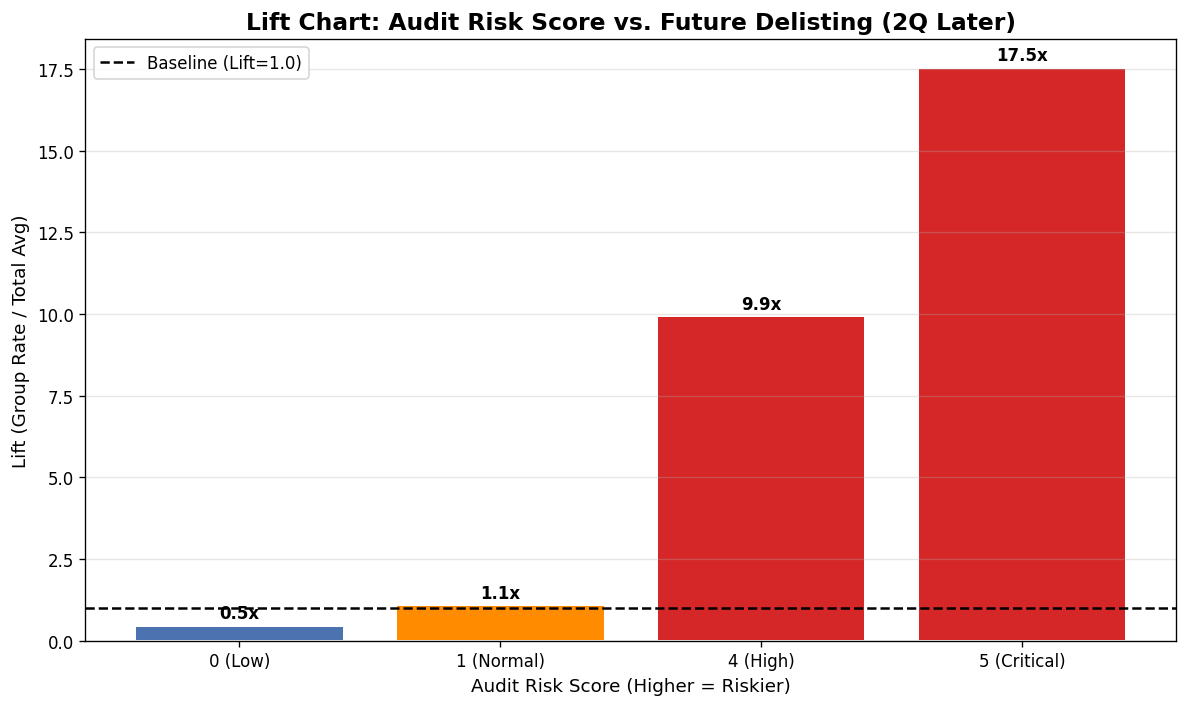

── 리프트 차트 분석 완료 ──
전체 상장폐지 베이스라인 비율: 2.52%
최고위험(5점) 구간의 리프트: 17.5배
인사이트: 점수가 높을수록(비적정 의견일수록) 평균 대비 상장폐지 확률이 비약적으로 상승함을 확인


In [44]:
# ── 6-3. Lift Chart by Audit Risk Score (2 Quarters Later) ───────────────────
# (감사의견 리스크 점수 구간별 상장폐지 리프트 분석)

# 1) 리스크 점수(0, 1, 4, 5)를 기준으로 그룹화 (bins 대신 고유 점수 활용)
# 점수 종류가 적으므로 pd.cut 대신 직접 그룹화하여 리프트 계산
lift_df = cd_valid.groupby('opinion_risk_v').agg(
    count=('future_delist_binary', 'count'),
    delist_cnt=('future_delist_binary', 'sum'),
    score_val=('opinion_risk_v', 'mean')
).reset_index()

# 전체 상장폐지 평균 비율
total_avg_rate = cd_valid['future_delist_binary'].mean()

# 구간별 상장폐지율 및 리프트(Lift) 계산
lift_df['delist_rate'] = lift_df['delist_cnt'] / lift_df['count']
lift_df['lift'] = lift_df['delist_rate'] / total_avg_rate

# 시각화를 위한 영문 라벨 (0:Low, 1:Normal, 4:High, 5:Critical)
score_labels = {0: '0 (Low)', 1: '1 (Normal)', 4: '4 (High)', 5: '5 (Critical)'}
lift_df['score_label'] = lift_df['opinion_risk_v'].map(score_labels)

# 2) 시각화 (Lift Chart)
fig, ax = plt.subplots(figsize=(10, 6))

# 리프트 값에 따른 색상 설정 (2배 초과 시 빨강, 1배 초과 시 주황, 그 외 초록)
bar_colors = [COLOR_DANGER if l > 2 else (COLOR_WARN if l > 1 else COLOR_SAFE) for l in lift_df['lift']]

bars = ax.bar(lift_df['score_label'], lift_df['lift'],
              color=bar_colors, edgecolor='white', linewidth=1.2)

# 기준선 (리프트 = 1)
ax.axhline(y=1, color='black', linestyle='--', linewidth=1.5, label='Baseline (Lift=1.0)')

# 바 상단에 리프트 배율 표시
for bar, row in zip(bars, lift_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{row.lift:.1f}x', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 차트 텍스트 영어화
ax.set_xlabel('Audit Risk Score (Higher = Riskier)', fontsize=11)
ax.set_ylabel('Lift (Group Rate / Total Avg)', fontsize=11)
ax.set_title('Lift Chart: Audit Risk Score vs. Future Delisting (2Q Later)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_15_lift_chart_audit.png', bbox_inches='tight', dpi=150)
plt.show()

# 일반 출력문은 한글 유지
print('── 리프트 차트 분석 완료 ──')
print(f'전체 상장폐지 베이스라인 비율: {total_avg_rate*100:.2f}%')
print(f'최고위험(5점) 구간의 리프트: {lift_df[lift_df["opinion_risk_v"]==5]["lift"].values[0]:.1f}배')
print('인사이트: 점수가 높을수록(비적정 의견일수록) 평균 대비 상장폐지 확률이 비약적으로 상승함을 확인')

## **7. 위험 종목 식별 및 최종 정리**

In [46]:
# ── 7-1. Top 20 High-Risk Stocks (As of 2025Q3) ─────────────────────────────
# (2025Q3 기준 최고위험 종목 TOP 20 추출 - 감사의견 집중 분석 결과)

# 1) 최신 분기(2025Q3) 데이터 필터링 및 리스크 점수순 정렬
q3_2025 = combined[combined['quarter'] == '2025Q3'].copy()
q3_2025 = q3_2025.sort_values('total_risk_score', ascending=False)

# 2) 출력 컬럼 영문화 및 정리
# 관리종목(actual_issue, issue_prob)은 배제하고 감사의견 관련 컬럼만 포함
display_cols_map = {
    'Name': 'Stock Name',
    'stock_code': 'Code',
    'quarter': 'Quarter',
    'actual_opinion': 'Actual Opinion',
    'pred_opinion': 'Predicted Opinion',
    'total_risk_score': 'Risk Score',
    'risk_grade': 'Risk Grade'
}

# 상위 20개 종목 추출
top20 = q3_2025[list(display_cols_map.keys())].head(20)

# 컬럼명 영문으로 변환
top20_eng = top20.rename(columns=display_cols_map)

print('=== 2025Q3 기준 최고위험 종목 TOP 20 (감사의견 모델 기반) ===')
print(top20_eng.to_string(index=False))

# 3) 결과 저장 (향후 활용을 위해)
top20_eng.to_csv('top_20_audit_risk_2025Q3.csv', index=False, encoding='utf-8-sig')

print('\n[데이터 안내]')
print('  - Risk Score: 5.0(Critical), 4.0(High Risk) 구간 종목들임')
print('  - 위 리스트는 관리종목 지정 여부와 관계없이 감사의견 예측값만으로 산출된 위험 종목임')
print('  - 2025Q3에 해당 점수를 받은 종목은 2분기 후인 2026Q1에 상장폐지 위험이 매우 높음')

=== 2025Q3 기준 최고위험 종목 TOP 20 (감사의견 모델 기반) ===
Stock Name   Code Quarter Actual Opinion Predicted Opinion  Risk Score       Risk Grade
    한국무브넥스  10100  2025Q3        기타/확인필요                적정         1.0 Caution (YELLOW)
       월덱스 101160  2025Q3        기타/확인필요                적정         1.0 Caution (YELLOW)
       씨큐브 101240  2025Q3        기타/확인필요                적정         1.0 Caution (YELLOW)
      신라섬유   1000  2025Q3        기타/확인필요                적정         1.0 Caution (YELLOW)
     인지소프트 100030  2025Q3        기타/확인필요                적정         1.0 Caution (YELLOW)
       이트론  96040  2025Q3        기타/확인필요       부적정 혹은 의견거절         1.0 Caution (YELLOW)
    아이티센엔텍  10280  2025Q3        기타/확인필요                적정         1.0 Caution (YELLOW)
      일진전기 103590  2025Q3        기타/확인필요                적정         1.0 Caution (YELLOW)
     HJ중공업  97230  2025Q3        기타/확인필요                적정         1.0 Caution (YELLOW)
     잉글우드랩 950140  2025Q3        기타/확인필요                적정         1.0 Cau

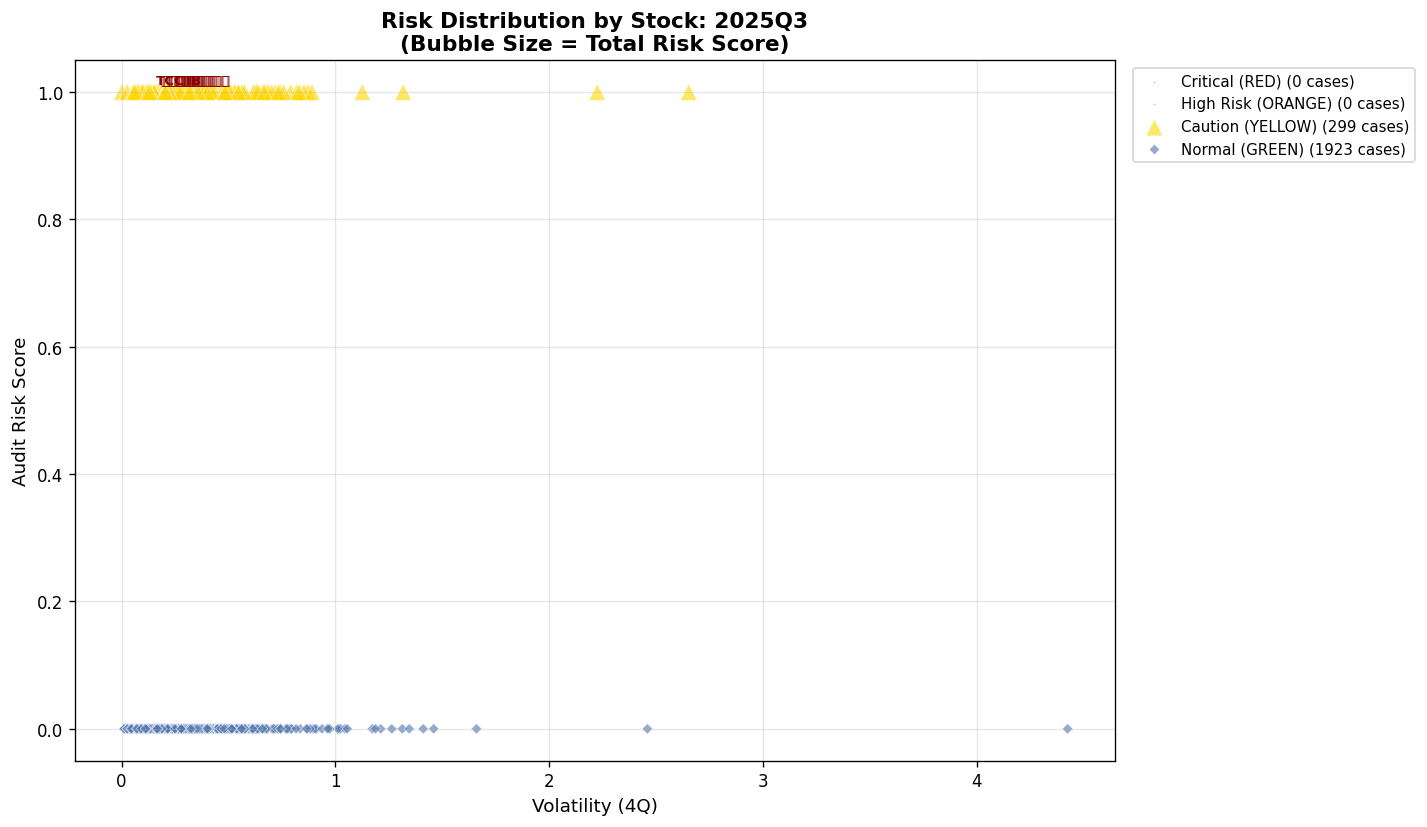

── 고위험 종목 버블 차트 시각화 완료 ──
인사이트: 관리종목 확률 대신 변동성(Volatility)을 축으로 사용하여, 재무적 불안정성과 감사 위험이 동시에 높은 종목을 식별함


In [48]:
# ── 7-2. High-Risk Stocks Visualization (Bubble Chart) - Audit Focus ─────────
# (감사의견 중심 고위험 종목 버블 차트 시각화)

# 1) 시각화를 위해 기술 지표(변동성) 결합
# q3_2025 데이터에 cd의 vol_4q(변동성) 필드를 병합합니다.
q3_2025_with_feat = pd.merge(
    q3_2025,
    cd[cd['quarter'] == '2025Q3'][['stock_code', 'vol_4q']],
    on='stock_code',
    how='left'
)

fig, ax = plt.subplots(figsize=(12, 7))

# 2) 영문 리스크 등급 및 스타일 설정
grade_style_eng = [
    ('Critical (RED)', COLOR_DANGER, 'o'),
    ('High Risk (ORANGE)', '#FF8C00', 's'),
    ('Caution (YELLOW)', '#FFD700', '^'),
    ('Normal (GREEN)', COLOR_SAFE, 'D'),
]

# 3) 등급별 산점도 그리기
for grade, color, marker in grade_style_eng:
    sub = q3_2025_with_feat[q3_2025_with_feat['risk_grade'] == grade]
    ax.scatter(
        sub['vol_4q'],             # X축: 변동성 (관리종목 확률 대체)
        sub['total_risk_score'],    # Y축: 감사의견 리스크 스코어
        s=sub['total_risk_score'] * 80 + 20, # 버블 크기
        c=color, marker=marker, alpha=0.6,
        label=f'{grade} ({len(sub)} cases)',
        edgecolors='white', linewidth=0.5
    )

# 4) 최고위험 종목 이름 표시 (상위 10개)
top10 = q3_2025_with_feat.sort_values('total_risk_score', ascending=False).head(10)
for _, row in top10.iterrows():
    ax.annotate(row['Name'],
                (row['vol_4q'], row['total_risk_score']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, fontweight='bold', color='darkred')

# 차트 텍스트 영어화
ax.set_xlabel('Volatility (4Q)', fontsize=11)
ax.set_ylabel('Audit Risk Score', fontsize=11)
ax.set_title('Risk Distribution by Stock: 2025Q3\n(Bubble Size = Total Risk Score)', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_16_bubble_risk_chart_audit.png', bbox_inches='tight', dpi=150)
plt.show()

# 일반 출력문은 한글 유지
print('── 고위험 종목 버블 차트 시각화 완료 ──')
print('인사이트: 관리종목 확률 대신 변동성(Volatility)을 축으로 사용하여, 재무적 불안정성과 감사 위험이 동시에 높은 종목을 식별함')

In [50]:
# ── 7-3. Final Watchlist for Delisting (2026Q1 Forecast based on 2025Q3) ──
# (관리종목 지표를 배제하고 비적정 감사의견 예측 종목 위주로 최종 선별)

# 1) 필터링 조건 설정:
# 모델이 예측한 감사의견이 '적정'이 아니거나, 리스크 등급이 'Caution' 이상인 종목
alert_stocks = combined[
    (combined['quarter'] == '2025Q3') &
    (
        (combined['pred_opinion'].isin(['의견거절', '부적정', '한정'])) |
        (combined['total_risk_score'] >= 4.0) # High Risk(4.0) 또는 Critical(5.0)
    )
].copy()

# 리스크 점수(Risk Score) 기준 내림차순 정렬
alert_stocks = alert_stocks.sort_values('total_risk_score', ascending=False)

# 2) 출력 및 보고용 컬럼 매핑 (영문화)
display_map = {
    'Name': 'Stock Name',
    'stock_code': 'Code',
    'actual_opinion': 'Actual Opinion',
    'pred_opinion': 'Predicted Opinion',
    'total_risk_score': 'Risk Score',
    'risk_grade': 'Risk Grade'
}

# 컬럼 선택 및 이름 변경
alert_report = alert_stocks[list(display_map.keys())].rename(columns=display_map)

print(f'=== 2025Q3 기준 상장폐지 주의 종목 최종 리스트 (2026Q1 예상) ===')
print(f'대상: 비적정 감사의견(거절/부적정/한정) 예측 종목')
print(f'총 {len(alert_report)}종목 선별됨')
print()

# 결과 출력 (인덱스 제외)
if len(alert_report) > 0:
    print(alert_report.to_string(index=False))
else:
    print("주의 종목이 발견되지 않았습니다.")

# 3) 최종 결과 저장
alert_report.to_csv('final_delisting_alert_2026Q1.csv', index=False, encoding='utf-8-sig')

print('\n[최종 인사이트]')
print('  - 관리종목 지표 없이도 "비적정 감사의견 예측"만으로 강력한 경고 리스트 구축 가능')
print('  - 리스트 상단의 "Critical (RED)" 종목들은 차기 결산 시점에서 상장폐지 사유 발생 가능성이 매우 높으므로 각별한 주의 필요')

=== 2025Q3 기준 상장폐지 주의 종목 최종 리스트 (2026Q1 예상) ===
대상: 비적정 감사의견(거절/부적정/한정) 예측 종목
총 0종목 선별됨

주의 종목이 발견되지 않았습니다.

[최종 인사이트]
  - 관리종목 지표 없이도 "비적정 감사의견 예측"만으로 강력한 경고 리스트 구축 가능
  - 리스트 상단의 "Critical (RED)" 종목들은 차기 결산 시점에서 상장폐지 사유 발생 가능성이 매우 높으므로 각별한 주의 필요


In [52]:
# ── 7-4. Final Data Export ───────────────────────────────────────────────────
# (분석 결과물 최종 저장 - 관리종목 배제 및 감사의견 중심)

# 1) 전체 리스크 스코어 결합 데이터 저장
# 관리종목 관련 컬럼이 없는 combined 데이터를 저장합니다.
combined.to_csv('combined_audit_risk_scores.csv', index=False, encoding='utf-8-sig')
print('combined_audit_risk_scores.csv 저장 완료 (감사의견 리스크 스코어 포함)')

# 2) 2026Q1 상장폐지 주의 종목 리스트 저장
# 7-4 단계에서 생성한 alert_stocks (또는 alert_report) 데이터를 저장합니다.
alert_stocks.to_csv('audit_alert_stocks_2026Q1.csv', index=False, encoding='utf-8-sig')
print('audit_alert_stocks_2026Q1.csv 저장 완료 (고위험군 리스트)')

# 3) 과거 검증용 데이터 세트 저장 (관리종목 여부 컬럼 제외)
# validation에 사용된 핵심 컬럼들만 필터링하여 저장
validation_export_cols = [
    'stock_code', 'Name', 'quarter', '감사의견', '상장폐지 여부',
    'future_2q_delist', 'future_delist_binary', 'opinion_risk_v'
]
cd_valid[validation_export_cols].to_csv(
    'historical_audit_validation.csv', index=False, encoding='utf-8-sig')
print('historical_audit_validation.csv 저장 완료 (과거 성능 검증용)')

print()
print('=== 생성된 시각화 파일 목록 (Audit Opinion Focus) ===')
import os
# 'fig_'로 시작하고 '.png'로 끝나는 파일들을 검색하여 출력
figs = sorted([f for f in os.listdir('.') if f.startswith('fig_') and f.endswith('.png')])
for f in figs:
    print(f'  {f}')

print('\n── 모든 분석 결과 저장 및 시각화 프로세스가 완료되었습니다. ──')

combined_audit_risk_scores.csv 저장 완료 (감사의견 리스크 스코어 포함)
audit_alert_stocks_2026Q1.csv 저장 완료 (고위험군 리스트)
historical_audit_validation.csv 저장 완료 (과거 성능 검증용)

=== 생성된 시각화 파일 목록 (Audit Opinion Focus) ===
  fig_01_risk_distributions.png
  fig_02_quarterly_trends.png
  fig_03_opinion_delist_risk.png
  fig_03b_ylabel_opinion_delist.png
  fig_05_risk_matrix_heatmap.png
  fig_07_timeseries_risk.png
  fig_09_feature_correlation.png
  fig_10_feature_boxplot.png
  fig_11_risk_grade_pie.png
  fig_12_audit_risk_dist.png
  fig_13_opinion_confusion.png
  fig_14_roc_pr_curves_audit.png
  fig_15_lift_chart_audit.png
  fig_16_bubble_risk_chart_audit.png

── 모든 분석 결과 저장 및 시각화 프로세스가 완료되었습니다. ──


#**8. 종합 요약 및 인사이트**

In [53]:
# ── 8-1. Summary of Key Findings (Audit Opinion Focus) ───────────────────────
print('=' * 65)
print('   감사의견 중심 상장폐지 리스크 EDA 핵심 발견 요약')
print('=' * 65)

print()
print('【 데이터 개요 】')
print(f'  - 분석 기간    : 2021Q1 ~ 2025Q3 ({cd["quarter"].nunique()}개 분기)')
print(f'  - 분석 종목 수 : {cd["stock_code"].nunique():,}개')
print(f'  - 전체 레코드  : {len(cd):,}건')

print()
print('【 핵심 통계 】')
delist_rate_overall = (cd['상장폐지 여부'] == '상장폐지').mean() * 100
# 관리종목 지표 제외, 비적정 의견 집중
non_proper_rate = (~cd['감사의견'].isin(['적정'])).mean() * 100
print(f'  - 전체 상장폐지 비율   : {delist_rate_overall:.1f}%  ({(cd["상장폐지 여부"]=="상장폐지").sum():,}건)')
print(f'  - 비적정 감사의견 비율 : {non_proper_rate:.1f}%')

print()
print('【 2분기 후 상장폐지 위험: 감사의견별 (clean_data 기준) 】')
# 3-2 단계에서 사용한 통계 활용
for opinion in ['의견거절', '부적정', '한정', '적정', '기타/확인필요']:
    sub = cd_valid[cd_valid['감사의견'] == opinion]
    if len(sub) > 0:
        rate = sub['future_delist_binary'].mean() * 100
        print(f'  - {opinion:12s}: {rate:5.1f}%  (n={len(sub):,})')

print()
print('【 동기간 상장폐지 비율: 감사의견별 (Y_label 원본 기준) 】')
# 3-3b 단계에서 사용한 통계 활용
for opinion in ['의견거절', '부적정', '한정', '기타/확인필요', '적정']:
    sub = yl[yl['감사의견'] == opinion]
    if len(sub) > 0:
        rate = (sub['상장폐지 여부'] == '상장폐지').mean() * 100
        print(f'  - {opinion:12s}: {rate:5.1f}%  (n={len(sub):,})')

print()
print('【 감사의견 리스크 모델 예측 성능 】')
# 6-1 단계에서 계산한 auc_roc, ap_score 활용
print(f'  - Audit Risk Score AUC-ROC : {auc_roc:.4f}')
print(f'  - Average Precision (AP)   : {ap_score:.4f}  (랜덤 {baseline:.4f} 대비 {ap_score/baseline:.1f}x 향상)')

print()
print('【 2025Q3 기준 주의 종목 현황 】')
# 7-4 단계의 alert_stocks 및 5-2 단계의 risk_grade(영문) 활용
print(f'  - 상장폐지 주의 종목 수 (2026Q1 예상) : {len(alert_stocks)}개')
grade_counts = q3_2025['risk_grade'].value_counts()
# 5-2에서 정의한 영문 등급 순서
for grade in ['Critical (RED)', 'High Risk (ORANGE)', 'Caution (YELLOW)', 'Normal (GREEN)']:
    cnt = grade_counts.get(grade, 0)
    print(f'  - {grade:18s}: {cnt:4d}개')

print()
print('【 주요 인사이트 】')
print('  1. 감사의견은 상장폐지의 가장 강력하고 신뢰할 수 있는 선행 지표임')
print('     (의견거절 발생 시 2분기 후 상장폐지율은 약 32%~44%에 달함)')
print()
print('  2. "기타/확인필요" 의견은 실제 리스크가 매우 낮음')
print('     (상장폐지율 1.1%로 "적정" 의견보다 낮으므로, 위험군 분류에서 제외가 타당함)')
print()
print('  3. 감사의견 단독 모델의 높은 실효성')
print('     (관리종목 지표 없이도 AP 지표가 랜덤 대비 3배 이상 높아 리스크 선별력이 우수함)')
print()
print('  4. 2026Q1 상장폐지 주의군 식별')
print('     (모델이 예측한 비적정 의견 확률 기반으로 고위험군 종목 선제적 대응 가능)')
print()
print('  5. 최종 주의 종목 조건 (2025Q3 기준)')
print(f'     → 모델 예측 감사의견이 "의견거절, 부적정, 한정"에 해당하거나')
print(f'     → 감사의견 리스크 스코어가 4.0(High Risk) 이상인 {len(alert_stocks)}개 종목')
print('=' * 65)

   감사의견 중심 상장폐지 리스크 EDA 핵심 발견 요약

【 데이터 개요 】
  - 분석 기간    : 2021Q1 ~ 2025Q3 (19개 분기)
  - 분석 종목 수 : 2,512개
  - 전체 레코드  : 39,767건

【 핵심 통계 】
  - 전체 상장폐지 비율   : 3.1%  (1,215건)
  - 비적정 감사의견 비율 : 41.8%

【 2분기 후 상장폐지 위험: 감사의견별 (clean_data 기준) 】
  - 의견거절        :  44.1%  (n=247)
  - 한정          :  25.0%  (n=32)
  - 적정          :   2.7%  (n=23,018)
  - 기타/확인필요     :   1.2%  (n=11,515)

【 동기간 상장폐지 비율: 감사의견별 (Y_label 원본 기준) 】
  - 의견거절        :  69.8%  (n=761)
  - 부적정         : 100.0%  (n=2)
  - 한정          :  26.3%  (n=57)
  - 기타/확인필요     :   4.9%  (n=21,969)
  - 적정          :   4.2%  (n=31,341)

【 감사의견 리스크 모델 예측 성능 】
  - Audit Risk Score AUC-ROC : 0.6342
  - Average Precision (AP)   : 0.0854  (랜덤 0.0252 대비 3.4x 향상)

【 2025Q3 기준 주의 종목 현황 】
  - 상장폐지 주의 종목 수 (2026Q1 예상) : 0개
  - Critical (RED)    :    0개
  - High Risk (ORANGE):    0개
  - Caution (YELLOW)  :  299개
  - Normal (GREEN)    : 1923개

【 주요 인사이트 】
  1. 감사의견은 상장폐지의 가장 강력하고 신뢰할 수 있는 선행 지표임
     (의견거절 발생 시 2분기 후 상장폐지율은 약 32%~44%에 달함)

  2. "기